# Name : Kapil Thakur
## Roll No : DS24MS16

## Classification
**Project :** InspireDirect Email Campaign Effectiveness Prediction

## Project Description:
#### Business Context
InspireDirect, a dynamic player in the email marketing industry, leverages Gmail-based
strategies to enhance its outreach and engagement with small to medium-sized businesses
(SMBs). The company specializes in creating targeted email campaigns designed to convert
potential customers into leads and foster long-term relationships with existing clients. The
company’s primary goal is to optimize email marketing efforts and increase the effectiveness of
their campaigns by understanding and predicting recipient behavior.
#### Objective:
InspireDirect aims to develop a machine learning model to analyze and characterize email
interactions. This model will be used to track and classify emails based on recipient actions,
including whether an email is ignored, read, or acknowledged. By leveraging various email
features and recipient data, InspireDirect seeks to improve the performance of its email
campaigns and enhance customer engagement. This information will enable InspireDirect to
tailor their email content, timing, and structure to better meet the needs and preferences of their
target audience. The expected outcomes include improved email open and click-through rates,
more effective segmentation of recipient lists, and ultimately, increased conversion rates for their
SMB clients. This data-driven approach will help InspireDirect stay competitive in the rapidly
evolving digital marketing landscape and deliver measurable value to their clients.

### Import Libraries
Each library plays a crucial role in tasks like cleaning data, visualizing patterns, building machine learning models, and measuring their performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

We load the dataset directly from filepath using pandas.read_csv.

In [2]:
df = pd.read_csv('data_email_campaign.csv')
df

,Email_ID,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
0,EMA00081000034500,1,2.2,2,E,2,33.0,1,440,8.0,0.0,0
1,EMA00081000045360,2,2.1,1,NaN,2,15.0,2,504,5.0,0.0,0
2,EMA00081000066290,2,0.1,1,B,3,36.0,2,962,5.0,0.0,1
3,EMA00081000076560,1,3.0,2,E,2,25.0,2,610,16.0,0.0,0
4,EMA00081000109720,1,0.0,2,C,3,18.0,2,947,4.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
68348,EMA00089995974500,2,0.4,1,F,2,22.0,3,737,16.0,13.0,0
68349,EMA00089998225300,1,1.3,1,C,2,40.0,2,653,31.0,16.0,0
68350,EMA00089998436500,1,2.2,2,NaN,2,33.0,2,490,9.0,0.0,0
68351,EMA00089999168800,1,0.4,1,E,2,50.0,1,733,14.0,4.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68353 entries, 0 to 68352
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Email_ID                   68353 non-null  object 
 1   Email_Type                 68353 non-null  int64  
 2   Subject_Hotness_Score      68353 non-null  float64
 3   Email_Source_Type          68353 non-null  int64  
 4   Customer_Location          56758 non-null  object 
 5   Email_Campaign_Type        68353 non-null  int64  
 6   Total_Past_Communications  61528 non-null  float64
 7   Time_Email_sent_Category   68353 non-null  int64  
 8   Word_Count                 68353 non-null  int64  
 9   Total_Links                66152 non-null  float64
 10  Total_Images               66676 non-null  float64
 11  Email_Status               68353 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 6.3+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Email_Type,68353.0,1.285094,0.451462,1.0,1.0,1.0,2.0,2.0
Subject_Hotness_Score,68353.0,1.095481,0.997578,0.0,0.2,0.8,1.8,5.0
Email_Source_Type,68353.0,1.456513,0.498109,1.0,1.0,1.0,2.0,2.0
Email_Campaign_Type,68353.0,2.272234,0.468680,1.0,2.0,2.0,3.0,3.0
Total_Past_Communications,61528.0,28.933250,12.536518,0.0,20.0,28.0,38.0,67.0
Time_Email_sent_Category,68353.0,1.999298,0.631103,1.0,2.0,2.0,2.0,3.0
Word_Count,68353.0,699.931751,271.719440,40.0,521.0,694.0,880.0,1316.0
Total_Links,66152.0,10.429526,6.383270,1.0,6.0,9.0,14.0,49.0
Total_Images,66676.0,3.550678,5.596983,0.0,0.0,0.0,5.0,45.0
Email_Status,68353.0,0.230934,0.497032,0.0,0.0,0.0,0.0,2.0


In [5]:
df.shape

(68353, 12)

In [6]:
df = df.drop(columns=['Email_ID'])

### Data Cleaning

This step ensures the dataset is error-free and ready for analysis.<br>
It includes:<br>
- Handling missing values: Missing data is removed or filled.<br>
- Converting data types: Ensuring features are in correct format (e.g., converting strings to numbers).<br>
- Removing duplicates: Ensures no repeated records exist, which could skew analysis.

In [7]:
df.isna().sum()

Email_Type                       0
Subject_Hotness_Score            0
Email_Source_Type                0
Customer_Location            11595
Email_Campaign_Type              0
Total_Past_Communications     6825
Time_Email_sent_Category         0
Word_Count                       0
Total_Links                   2201
Total_Images                  1677
Email_Status                     0
dtype: int64

In [8]:
df['Customer_Location'] = df['Customer_Location'].fillna('Unknown')

In [9]:
df = df.dropna(subset=['Total_Past_Communications', 'Total_Links','Total_Images'])

In [10]:
df.isna().sum()

Email_Type                   0
Subject_Hotness_Score        0
Email_Source_Type            0
Customer_Location            0
Email_Campaign_Type          0
Total_Past_Communications    0
Time_Email_sent_Category     0
Word_Count                   0
Total_Links                  0
Total_Images                 0
Email_Status                 0
dtype: int64

In [11]:
df.head()

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
0,1,2.2,2,E,2,33.0,1,440,8.0,0.0,0
1,2,2.1,1,Unknown,2,15.0,2,504,5.0,0.0,0
2,2,0.1,1,B,3,36.0,2,962,5.0,0.0,1
3,1,3.0,2,E,2,25.0,2,610,16.0,0.0,0
4,1,0.0,2,C,3,18.0,2,947,4.0,0.0,0


In [12]:
df.shape

(58091, 11)

- The number of columns has not decreased drastically so we can continue with next steps

# EXPLORATORY DATA ANALYSIS

In [13]:
for i in df.columns:
    print(f"Unique values for column {i} :\nNo of Unique values is {df[i].nunique()}\n{df[i].unique()}\n \n")


Unique values for column Email_Type :
No of Unique values is 2
[1 2]
 

Unique values for column Subject_Hotness_Score :
No of Unique values is 51
[2.2 2.1 0.1 3.  0.  3.2 0.7 0.5 0.2 1.  1.9 1.6 0.3 1.1 2.3 1.4 0.8 0.6
 4.2 1.8 1.7 2.4 0.9 3.3 2.8 2.6 3.1 1.3 4.1 2.9 1.5 2.7 0.4 1.2 2.  3.7
 2.5 3.8 4.6 4.5 3.6 3.4 3.5 4.4 4.7 5.  3.9 4.3 4.  4.8 4.9]
 

Unique values for column Email_Source_Type :
No of Unique values is 2
[2 1]
 

Unique values for column Customer_Location :
No of Unique values is 8
['E' 'Unknown' 'B' 'C' 'G' 'D' 'F' 'A']
 

Unique values for column Email_Campaign_Type :
No of Unique values is 3
[2 3 1]
 

Unique values for column Total_Past_Communications :
No of Unique values is 64
[33. 15. 36. 25. 18. 34. 21. 40. 27. 24. 42. 23. 37. 35. 51.  9. 39. 31.
 50. 30. 14. 53. 28.  7. 52. 22. 43. 16. 11. 20. 41. 45. 56. 26. 29.  5.
 32. 44. 10. 38. 46. 17. 47. 48.  8. 49.  0.  6. 55. 19. 60. 59. 13. 12.
 54. 62. 57. 58. 65. 61. 66. 67. 63. 64.]
 

Unique values for column

In [14]:
df['Customer_Location'].value_counts()

Customer_Location
G          19756
Unknown     9800
E           8660
D           6257
C           4893
F           3771
B           3726
A           1228
Name: count, dtype: int64

In [15]:
df['Total_Past_Communications'] = df['Total_Past_Communications'].astype(int)
df['Total_Images'] = df['Total_Images'].astype(int)

In [16]:
df['Customer_Location'] = df['Customer_Location'].astype('category')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58091 entries, 0 to 68352
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Email_Type                 58091 non-null  int64   
 1   Subject_Hotness_Score      58091 non-null  float64 
 2   Email_Source_Type          58091 non-null  int64   
 3   Customer_Location          58091 non-null  category
 4   Email_Campaign_Type        58091 non-null  int64   
 5   Total_Past_Communications  58091 non-null  int64   
 6   Time_Email_sent_Category   58091 non-null  int64   
 7   Word_Count                 58091 non-null  int64   
 8   Total_Links                58091 non-null  float64 
 9   Total_Images               58091 non-null  int64   
 10  Email_Status               58091 non-null  int64   
dtypes: category(1), float64(2), int64(8)
memory usage: 4.9 MB


## Visualization

#### Univariate Analysis

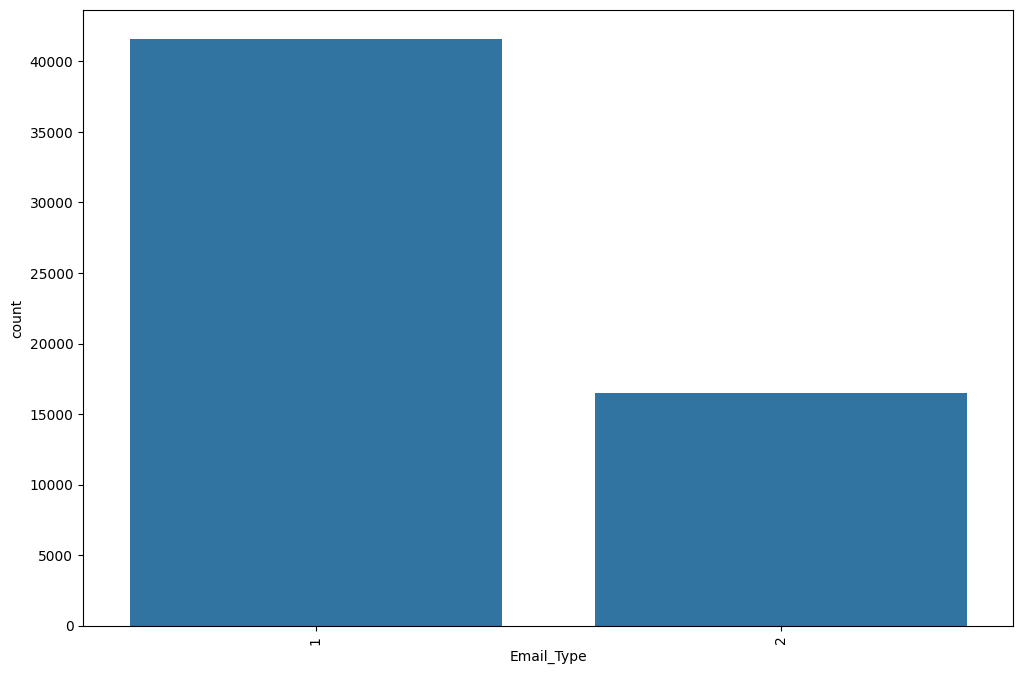

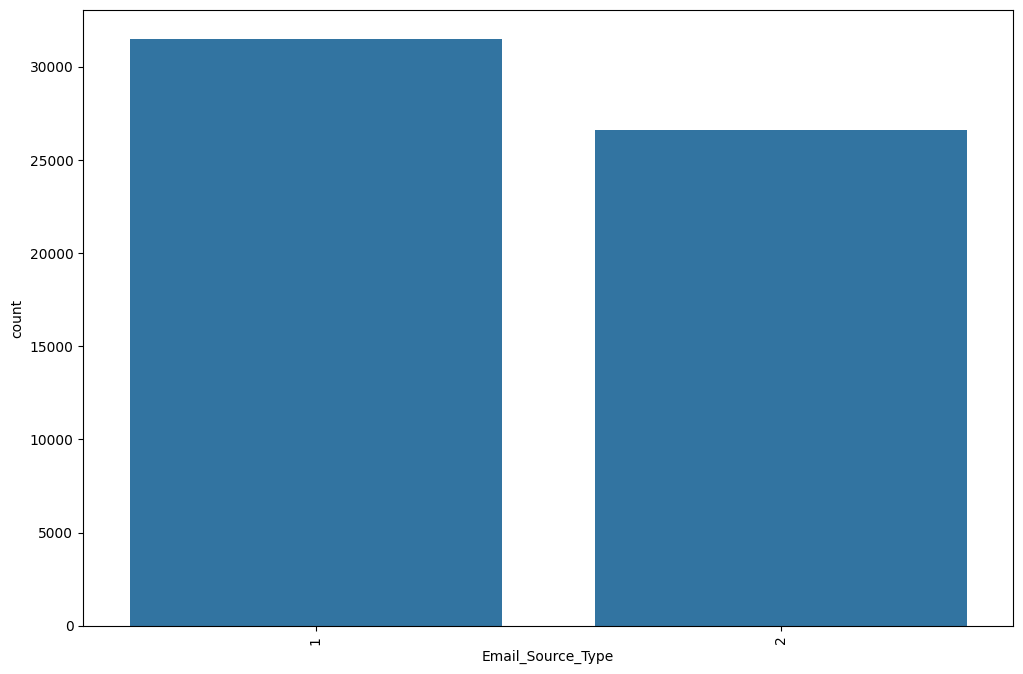

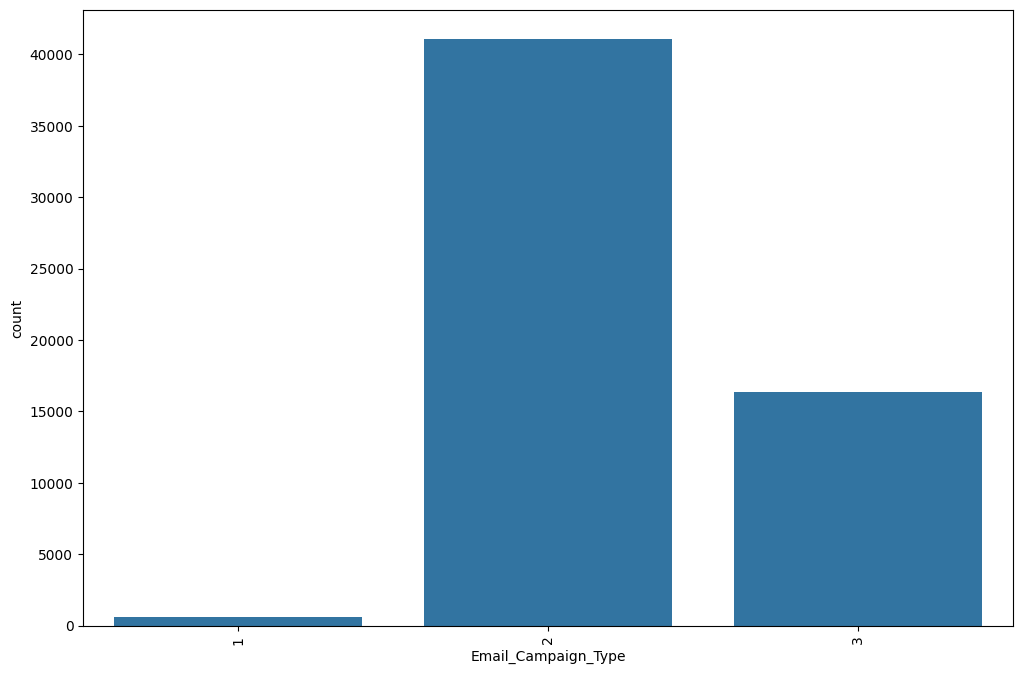

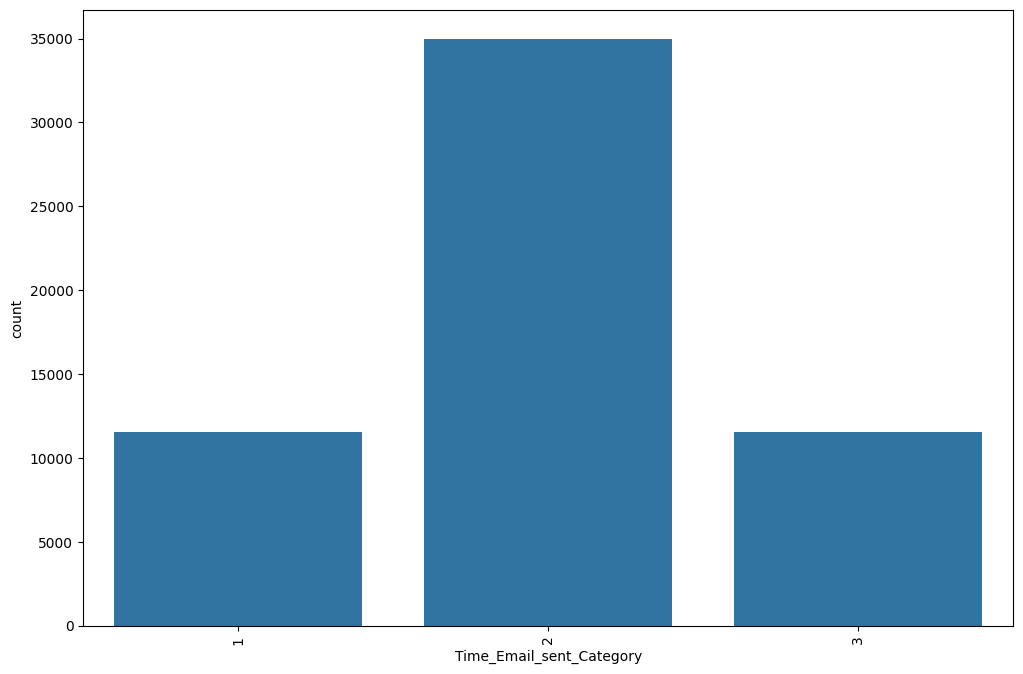

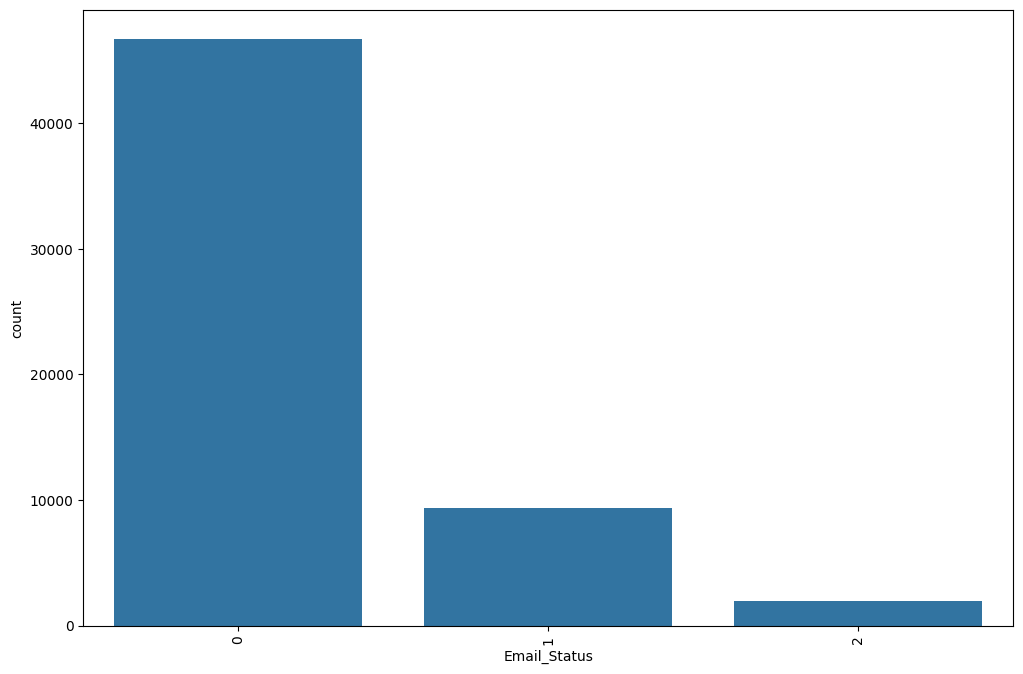

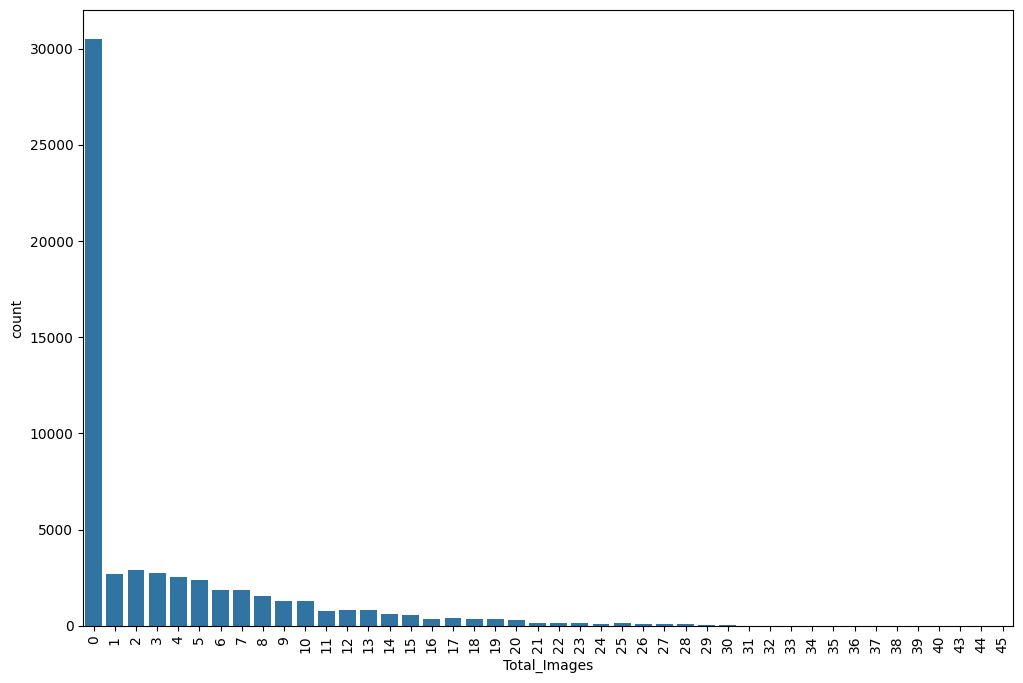

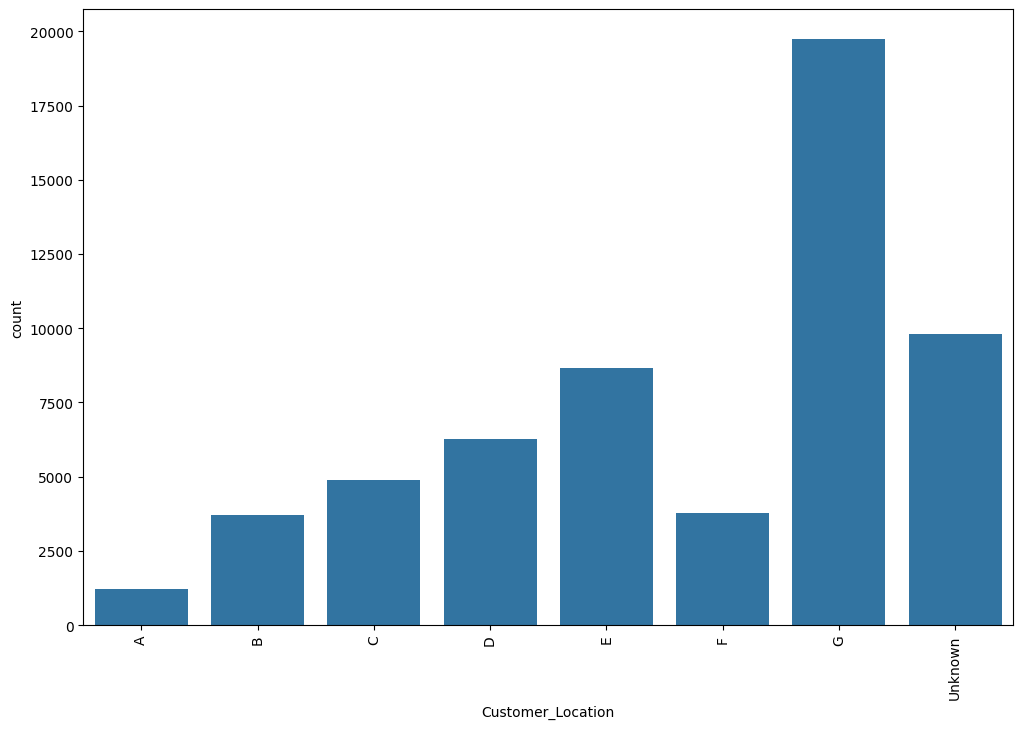

In [18]:
for i in ['Email_Type', 'Email_Source_Type', 'Email_Campaign_Type', 'Time_Email_sent_Category', 'Email_Status', 'Total_Images', 'Customer_Location']:
    plt.figure(figsize=(12,8))
    sns.countplot(data=df, x=i)
    plt.xticks(rotation=90)
    plt.show()

- Data is dominated by the email type 1
- Email Source Type is fairly balanced
- The Data has many emails of campaign type 2
- Email are generally sent during the 2 shift of the day
- The emails are generally ignored in this dataset
- Most of the emails do not have a image
- The most dominant locations of customers is G

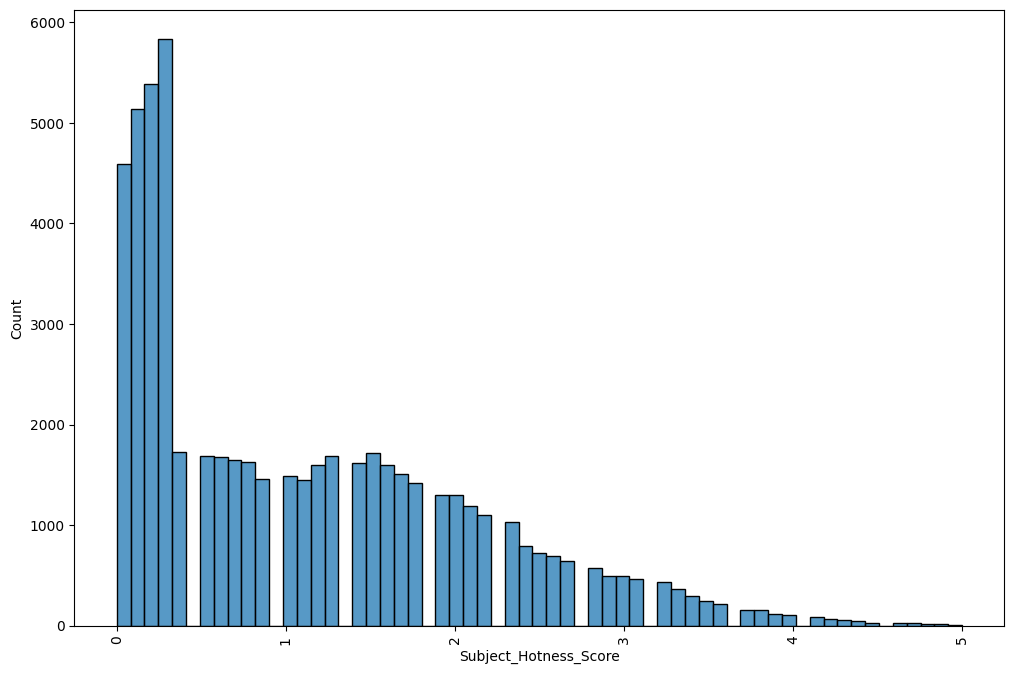

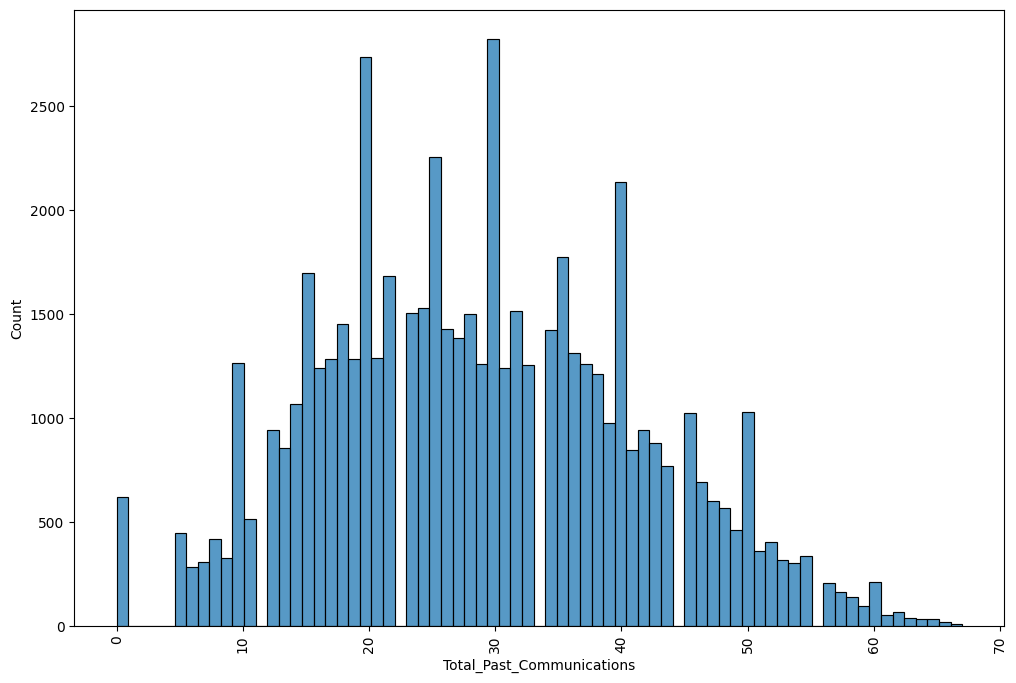

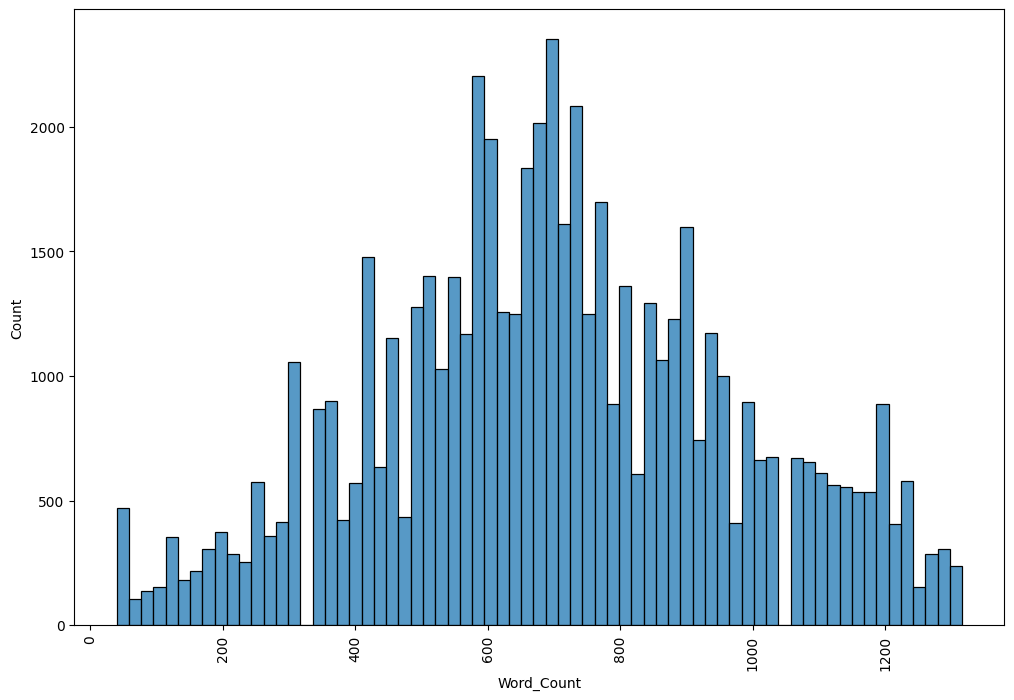

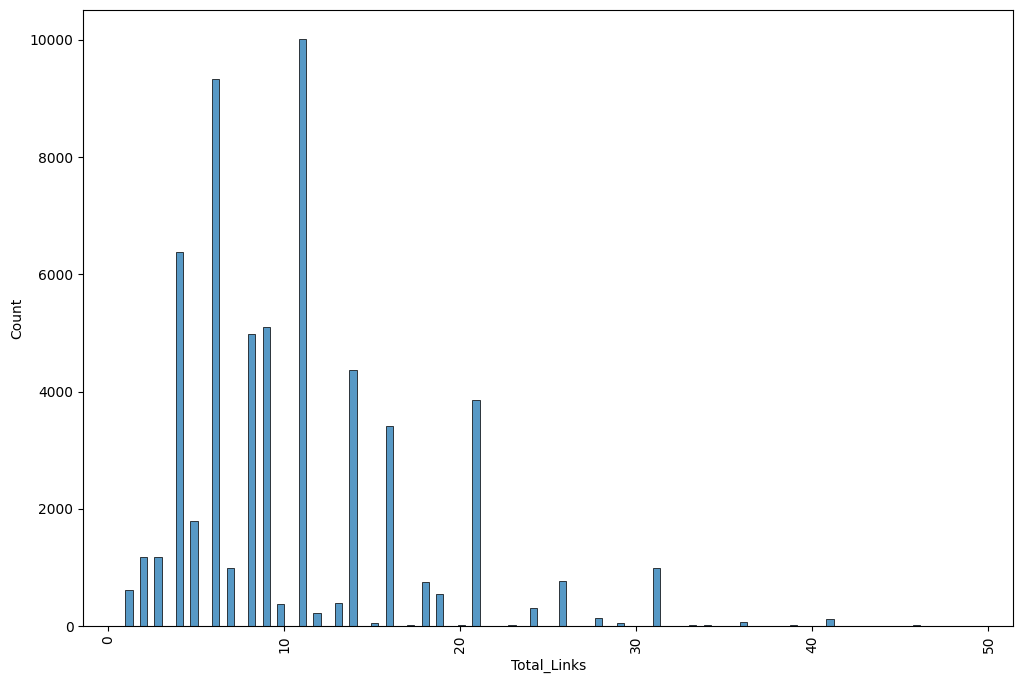

In [19]:
for i in ['Subject_Hotness_Score','Total_Past_Communications','Word_Count', 'Total_Links']:
    plt.figure(figsize=(12,8))
    sns.histplot(data=df, x=i)
    plt.xticks(rotation=90)
    plt.show()

- Subject hotness is pretty less for most emails
- Total Past communications is normally distributed
- Word count is also fairly normal
- Total links has no peculiar distribution but shows a right skewed distribution. ( Maybe log normal )

### Bivariate Analysis

In [20]:
df.head()

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
0,1,2.2,2,E,2,33,1,440,8.0,0,0
1,2,2.1,1,Unknown,2,15,2,504,5.0,0,0
2,2,0.1,1,B,3,36,2,962,5.0,0,1
3,1,3.0,2,E,2,25,2,610,16.0,0,0
4,1,0.0,2,C,3,18,2,947,4.0,0,0


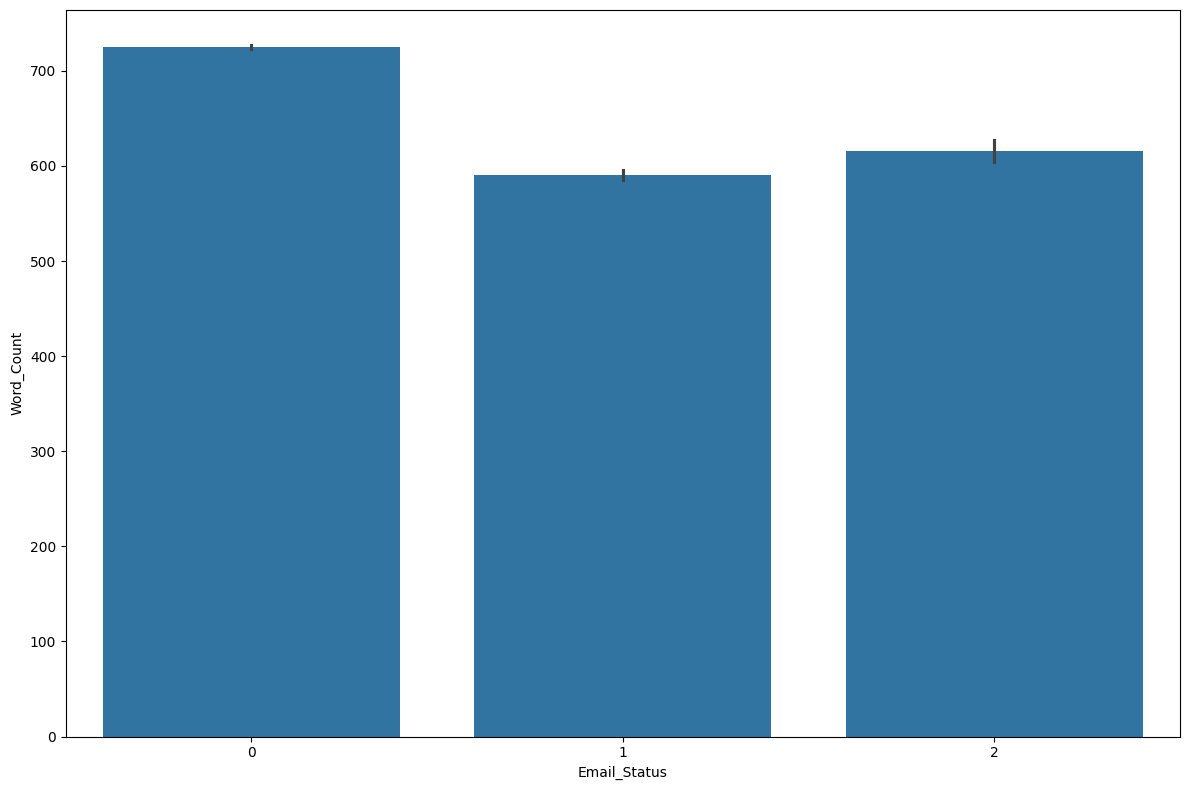

In [21]:
plt.figure(figsize=(12,8))
sns.barplot(df, x='Email_Status', y = 'Word_Count')
plt.tight_layout()
plt.show()

- The emails which are ignored have the highest word count.
- The emails which are read have a low word count
- This means users tend to read only short emails

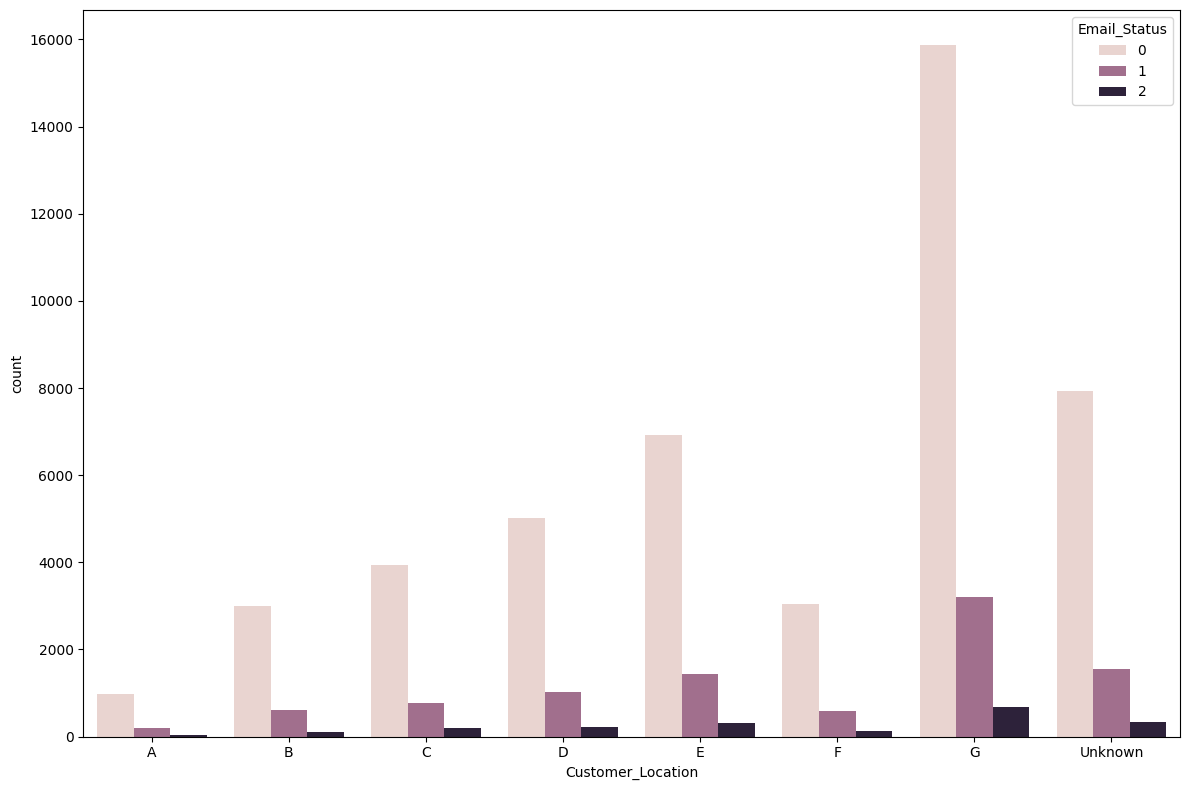

In [22]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='Customer_Location', hue='Email_Status')
plt.tight_layout()
plt.show()

- Almost all emails from all locations are ignored

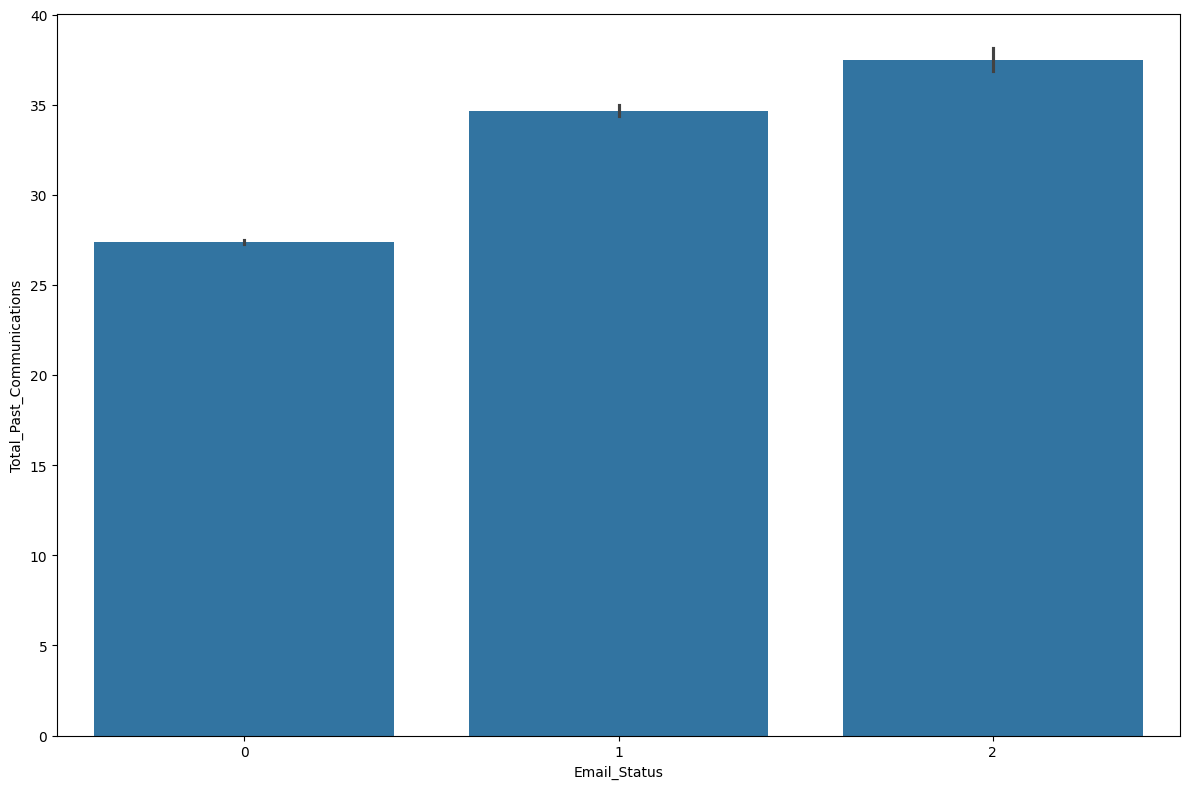

In [23]:
plt.figure(figsize=(12,8))
sns.barplot(df, y='Total_Past_Communications', x = 'Email_Status')
plt.tight_layout()
plt.show()

- Emails which are acknowledged by the user have a high past communication number

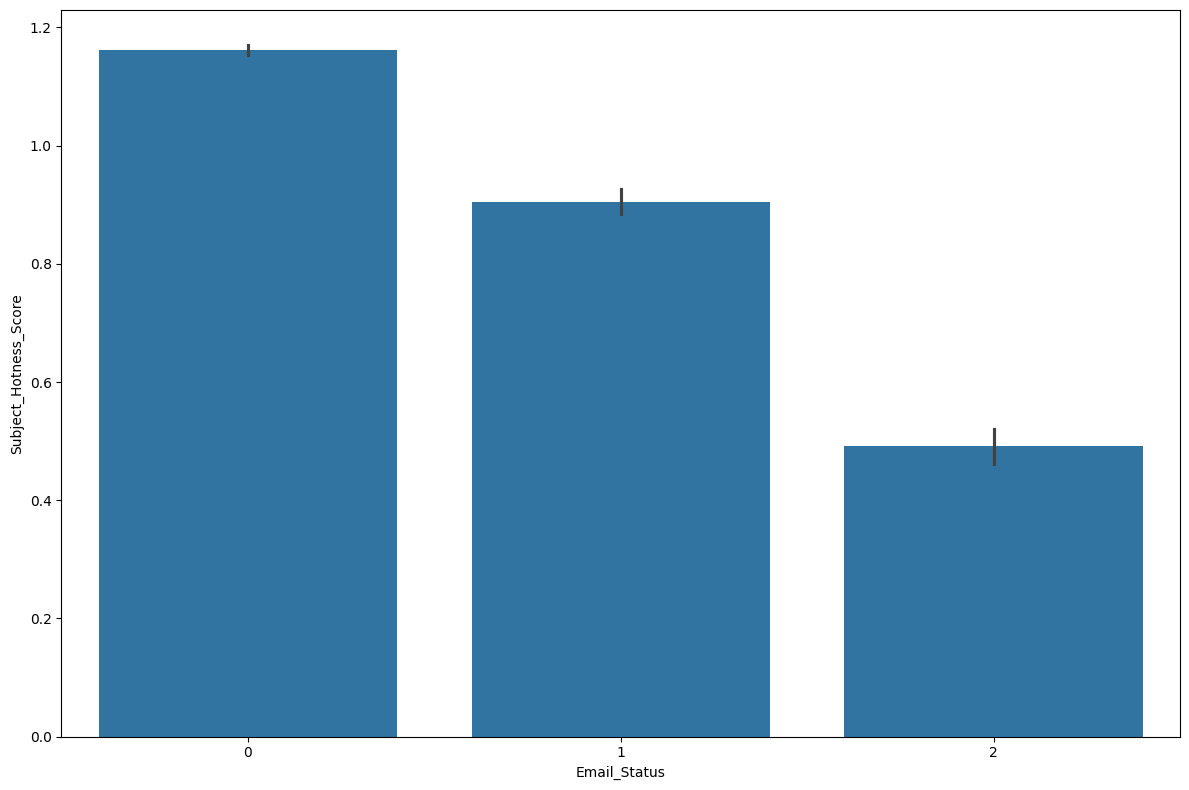

In [24]:
plt.figure(figsize=(12,8))
sns.barplot(df, y='Subject_Hotness_Score', x = 'Email_Status')
plt.tight_layout()
plt.show()

- Generally company or promotional emails have a very good content so their hotmess score becomes high. Also users tend to ignore this messages.
- Mails which are acknowledged have a low hotness score

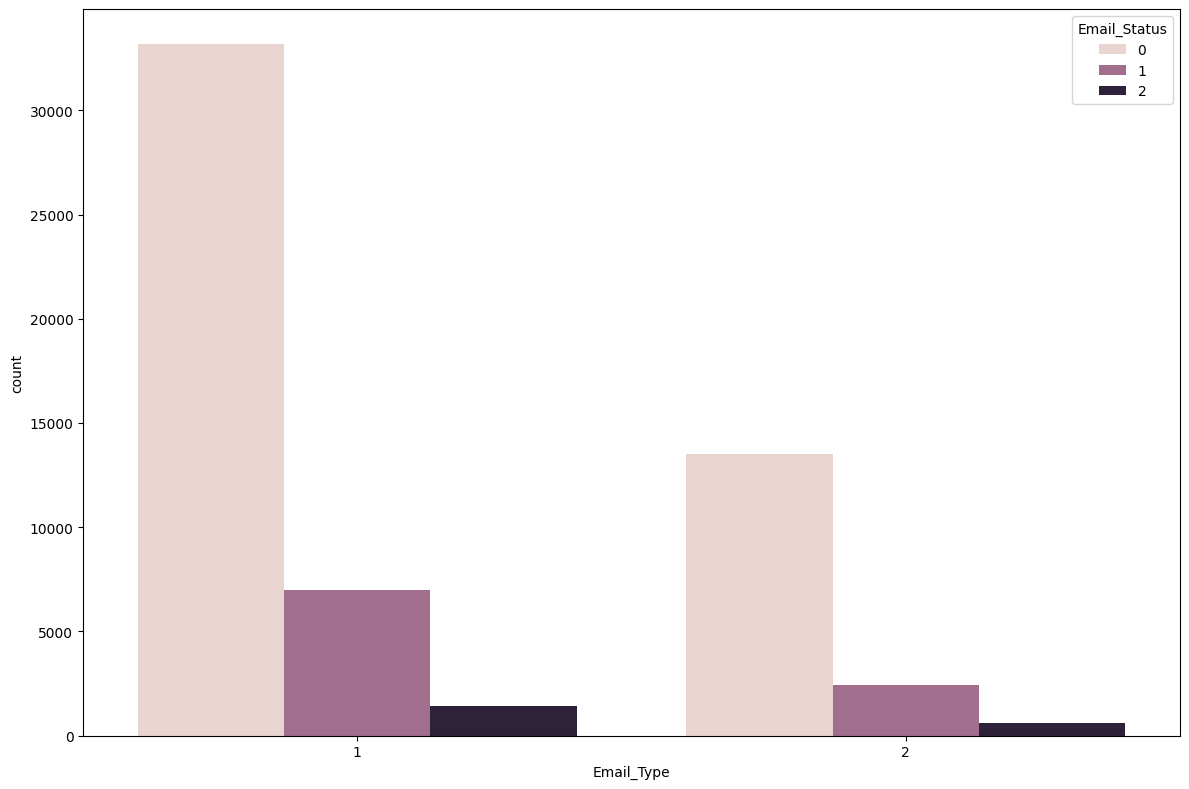

In [25]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='Email_Type', hue='Email_Status')
plt.tight_layout()
plt.show()

- Email type 1 has highest ignored mails and also highest read mails

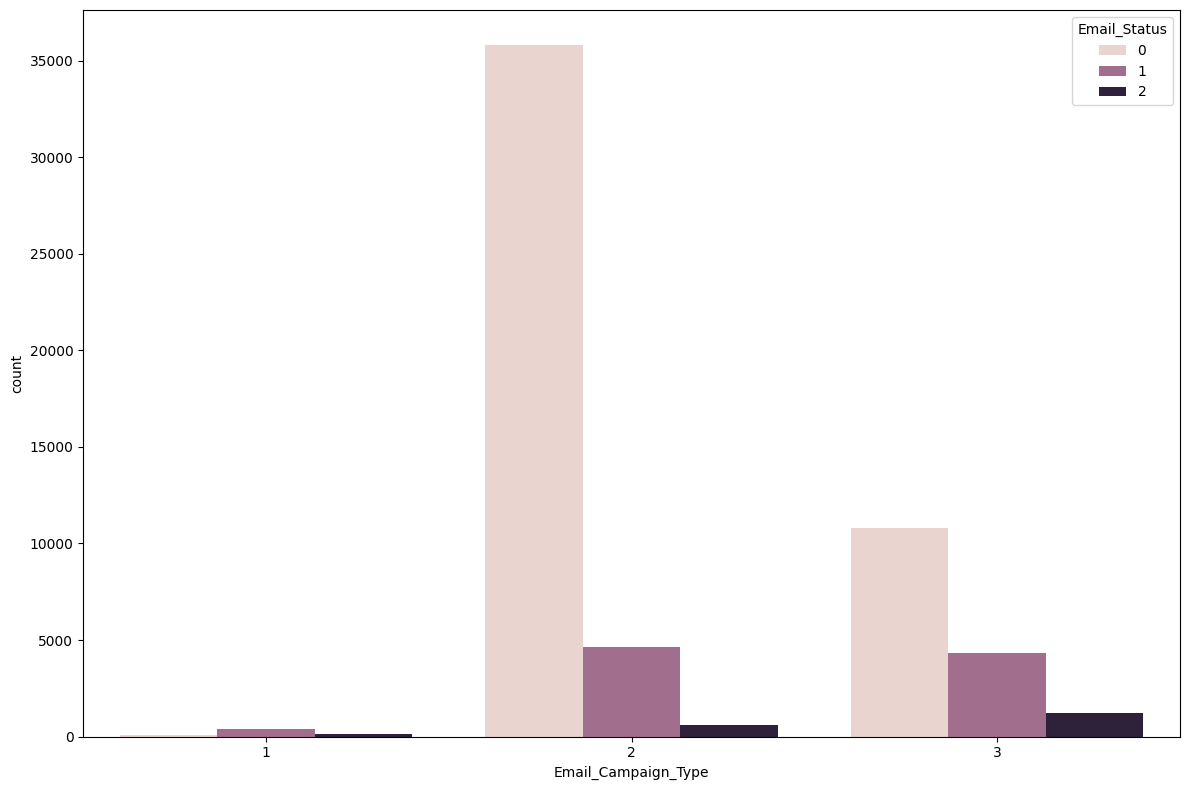

In [26]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='Email_Campaign_Type', hue='Email_Status')
plt.tight_layout()
plt.show()

- Comparatively campaign 1 has very low ignored messages as compared to read and acknowledged. This is a sign of successful campaign.
- Campaign 2 has highest ignored mails. Showing a failed campaign.

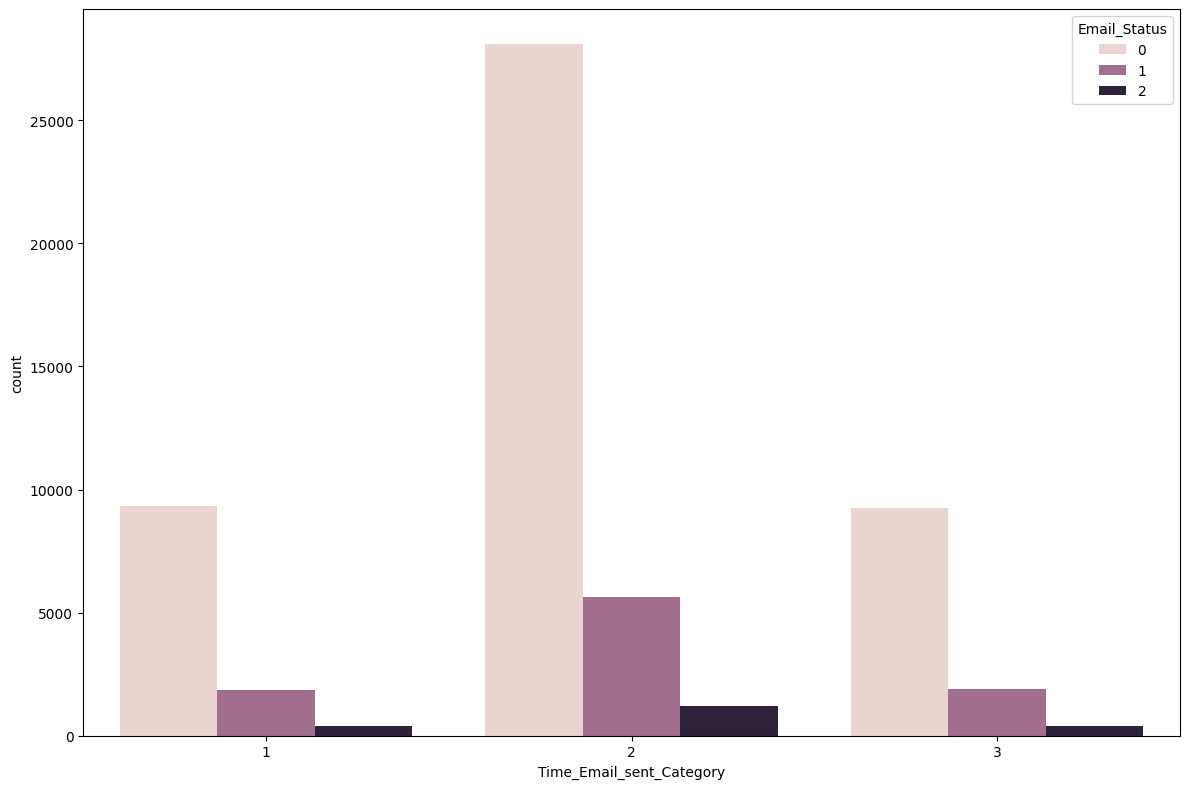

In [27]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='Time_Email_sent_Category', hue='Email_Status')
plt.tight_layout()
plt.show() 

### Multivariate Analysis

In [28]:
df.head()

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
0,1,2.2,2,E,2,33,1,440,8.0,0,0
1,2,2.1,1,Unknown,2,15,2,504,5.0,0,0
2,2,0.1,1,B,3,36,2,962,5.0,0,1
3,1,3.0,2,E,2,25,2,610,16.0,0,0
4,1,0.0,2,C,3,18,2,947,4.0,0,0


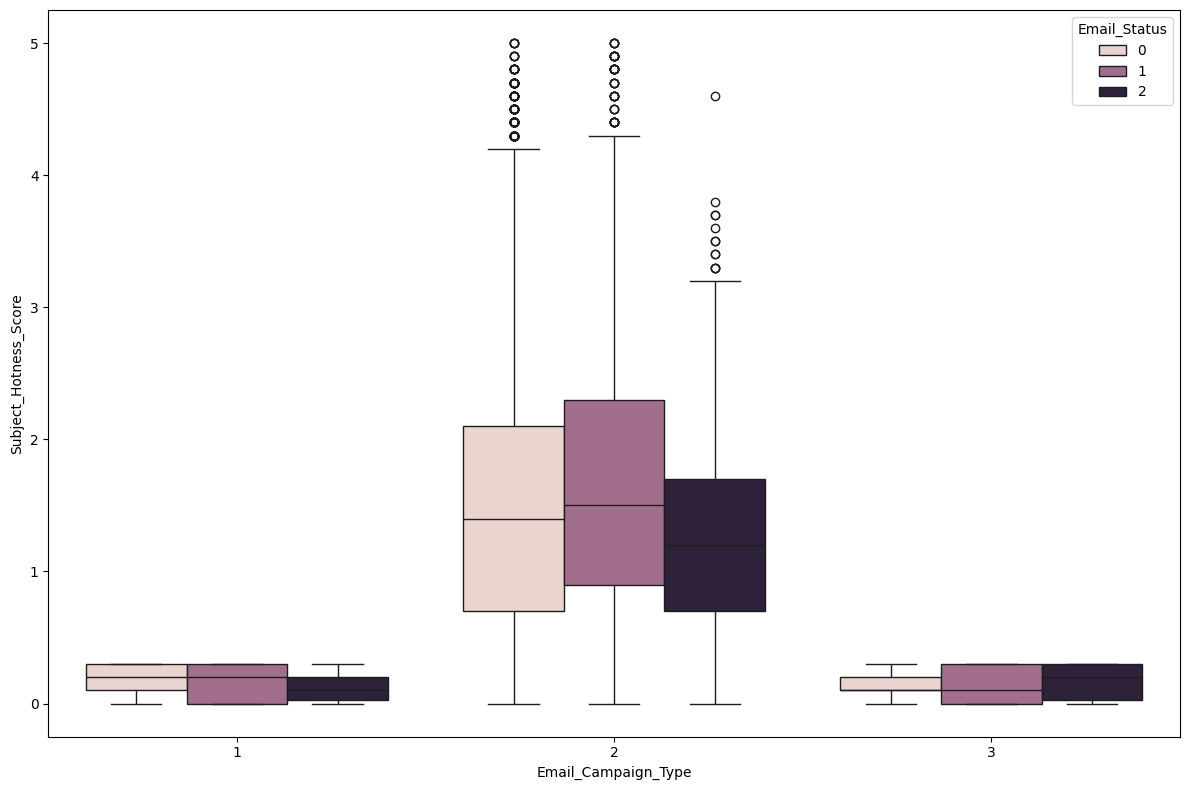

In [29]:
plt.figure(figsize=(12,8))
sns.boxplot(df, y='Subject_Hotness_Score',x='Email_Campaign_Type' ,hue = 'Email_Status')
plt.tight_layout()
plt.show()

- Emails in Campaign 2 which are read have highest subject score
- Emails in campaign 1 which are acknowledge have lowest subject score

In [30]:
# sns.pairplot(df, hue='Email_Status')

### Correlation Analysis

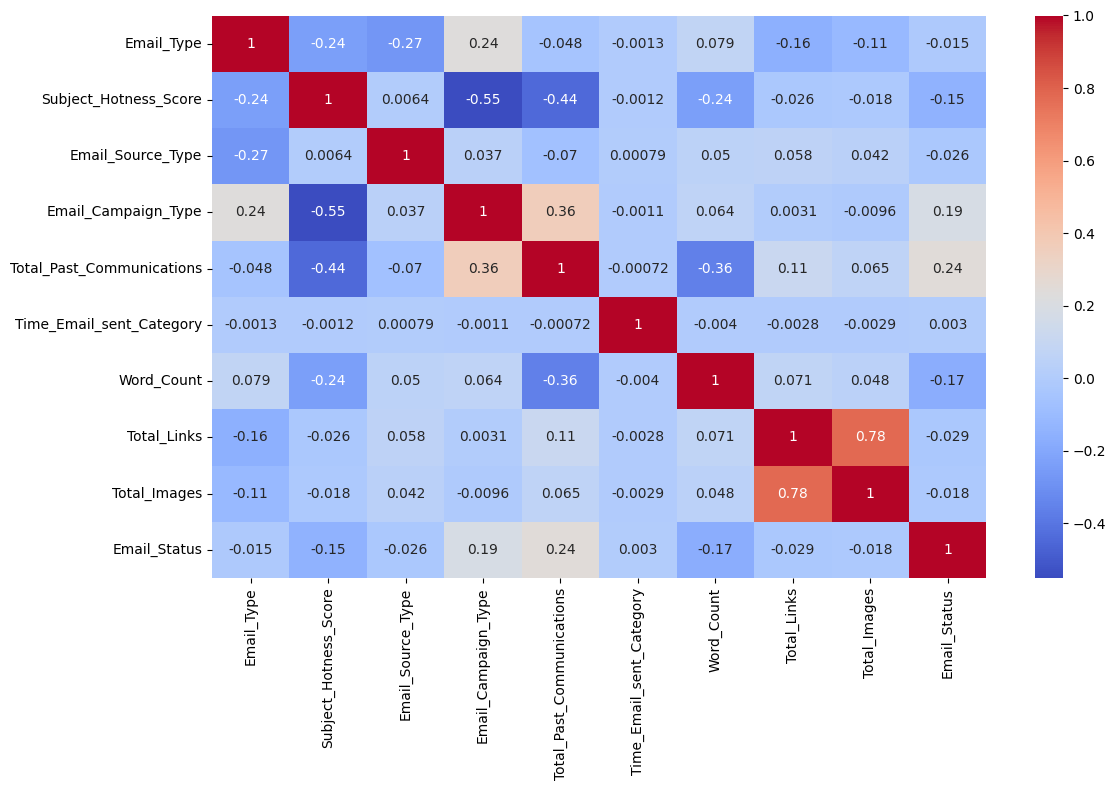

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm')
plt.tight_layout()

- Total Links and Total Images have highest correlation
- Subject Score and Campaign type have lowest correlation score

## Outlier Treatment

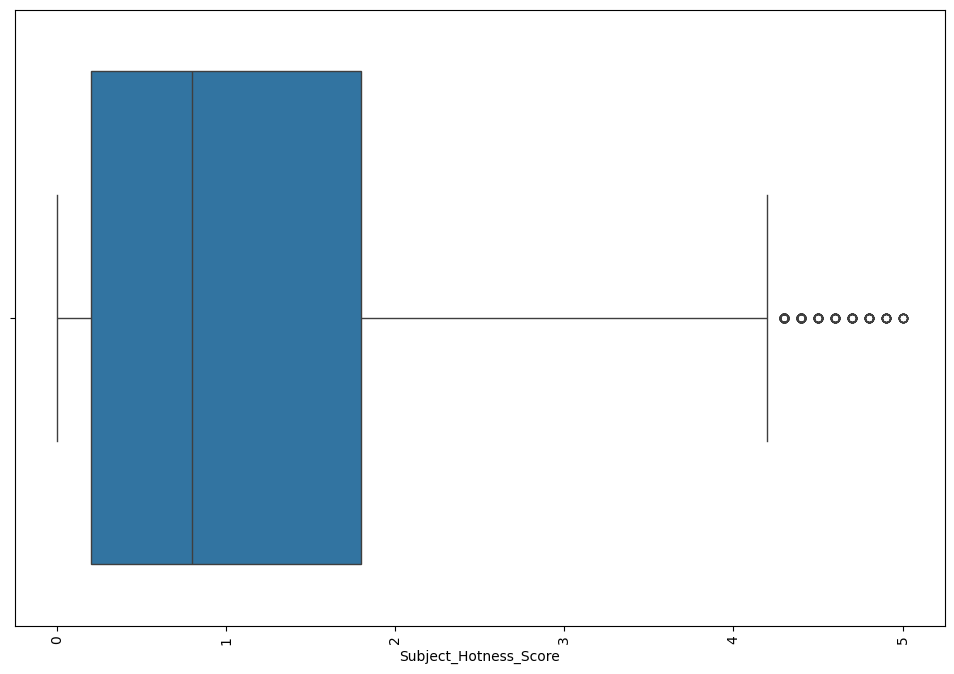

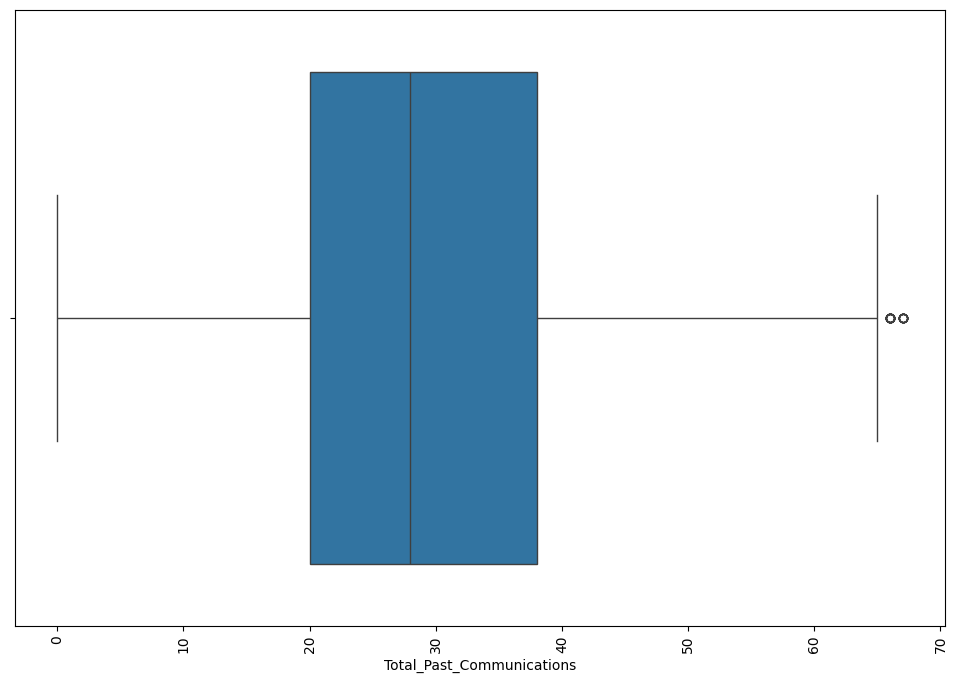

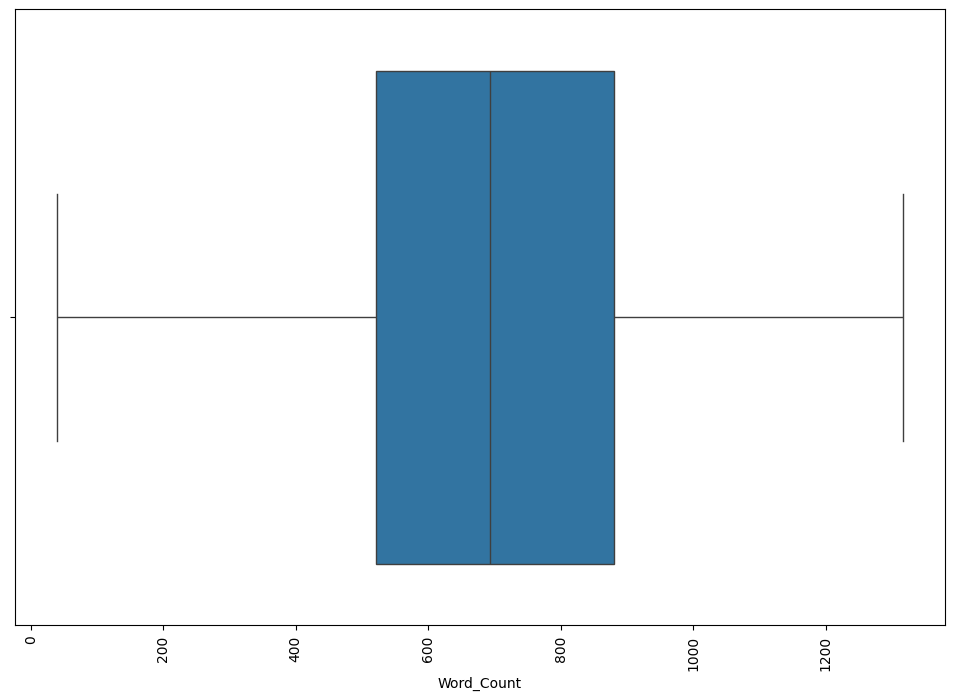

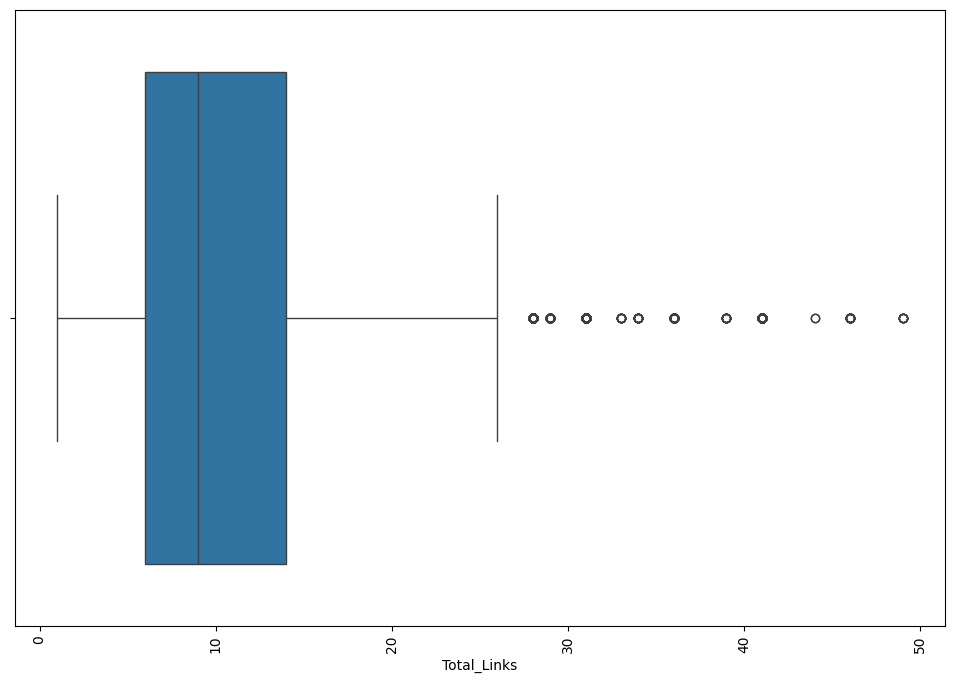

In [32]:
for i in ['Subject_Hotness_Score','Total_Past_Communications','Word_Count', 'Total_Links']:
    plt.figure(figsize=(12,8))
    sns.boxplot(data=df, x=i)
    plt.xticks(rotation=90)
    plt.show()

In [33]:
df[df['Total_Links'].quantile(0.97) < df['Total_Links']]

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
24,1,2.3,2,E,2,18,2,649,31.0,28,0
107,1,0.2,1,G,3,44,1,904,28.0,21,1
161,1,2.0,1,G,2,23,2,1157,41.0,25,0
179,1,0.8,1,B,2,30,2,636,41.0,24,0
226,1,1.6,1,B,2,33,2,424,31.0,25,1
...,...,...,...,...,...,...,...,...,...,...,...
68243,1,2.0,2,G,2,21,2,1014,31.0,18,0
68255,1,0.3,2,B,3,46,3,655,31.0,21,2
68264,1,1.4,1,D,2,40,1,653,29.0,28,0
68291,1,0.2,1,G,3,26,2,966,31.0,22,0


- Removing Outliers from Total Images is like manipulating the data
- So we let is be like that

In [34]:
df[4.2 < df['Subject_Hotness_Score']]

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
426,1,4.6,2,G,2,10,3,132,6.0,0,0
481,2,4.5,1,Unknown,2,20,1,233,31.0,14,1
699,1,4.4,1,Unknown,2,21,2,40,9.0,0,0
987,1,4.7,2,E,2,14,2,40,31.0,26,0
991,1,5.0,2,E,2,10,2,40,2.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
66431,2,4.5,1,G,2,12,2,314,4.0,0,0
66551,1,4.3,1,Unknown,2,12,2,233,5.0,3,0
66760,1,4.4,1,A,2,17,2,152,6.0,0,0
66823,1,4.3,1,G,2,14,2,565,6.0,0,0


- Subject Hotness Score also carries important info so we do not remove outliers from it

# Distributions and Transformations

### Distributions

In [35]:
for col in ['Subject_Hotness_Score','Total_Past_Communications','Word_Count', 'Total_Links']:
    print(f"Skewness for {col} is: {df[col].skew()}")
    print(f"Kurtosis for {col} is: {df[col].kurt()}")
    print()

Skewness for Subject_Hotness_Score is: 0.894654755527627
Kurtosis for Subject_Hotness_Score is: 0.07252187000266552

Skewness for Total_Past_Communications is: 0.21486030489881572
Kurtosis for Total_Past_Communications is: -0.4352037462386109

Skewness for Word_Count is: 0.013929153087365913
Kurtosis for Word_Count is: -0.3495488036939647

Skewness for Total_Links is: 1.3835246696277361
Kurtosis for Total_Links is: 2.473000794583482



- The Subject_Hotness_Score 
+ Has near to 1 skew so it is right skewed
+ Has near to 0 kurtosis

- The Total_Past_Communications 
+ Has near to 0 skew
+ Has near to -ve kurtosis so it has flat curve

- The Word_Count 
+ Has near to 0 skew
+ Has near to -ve kurtosis so it has flat curve

- The Total_Links 
+ Has +ve skew so right skewed data
+ Has +ve kurtosis so it has peaked curve


### Transformations


- We apply the sqrt to Total Links column to make it nearly normal distribution

In [36]:
df['Total_Links'] = np.sqrt(df['Total_Links'])

<Axes: >

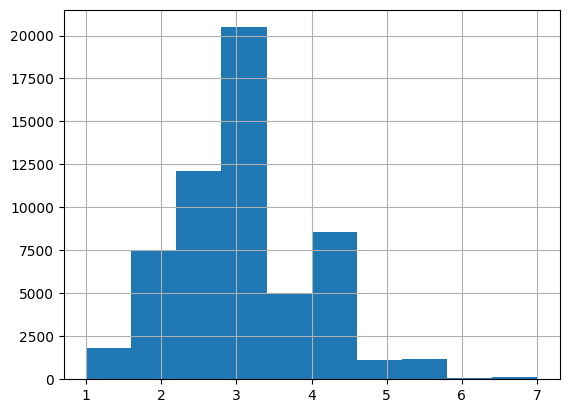

In [37]:
df['Total_Links'].hist()

# Feature Engineering

In [38]:
df.head()

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
0,1,2.2,2,E,2,33,1,440,2.828427,0,0
1,2,2.1,1,Unknown,2,15,2,504,2.236068,0,0
2,2,0.1,1,B,3,36,2,962,2.236068,0,1
3,1,3.0,2,E,2,25,2,610,4.000000,0,0
4,1,0.0,2,C,3,18,2,947,2.000000,0,0


In [39]:
cat_cols = df.select_dtypes('category').columns
cat_cols

Index(['Customer_Location'], dtype='object')

In [40]:
df_encoded = pd.get_dummies(df, columns=cat_cols)

In [41]:
df_encoded.head()

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status,Customer_Location_A,Customer_Location_B,Customer_Location_C,Customer_Location_D,Customer_Location_E,Customer_Location_F,Customer_Location_G,Customer_Location_Unknown
0,1,2.2,2,2,33,1,440,2.828427,0,0,False,False,False,False,True,False,False,False
1,2,2.1,1,2,15,2,504,2.236068,0,0,False,False,False,False,False,False,False,True
2,2,0.1,1,3,36,2,962,2.236068,0,1,False,True,False,False,False,False,False,False
3,1,3.0,2,2,25,2,610,4.000000,0,0,False,False,False,False,True,False,False,False
4,1,0.0,2,3,18,2,947,2.000000,0,0,False,False,True,False,False,False,False,False


# Splitting Data into Train-Test

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X = df_encoded.drop(columns=['Email_Status'])
y = df_encoded['Email_Status']

In [44]:
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [45]:
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(46472, 17) (11619, 17)
(46472,) (11619,)


# Training a Logistic Regression Model

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, f1_score

In [47]:
def model_scoring(y_pred, y_test):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()    
    print(classification_report(y_test, y_pred, zero_division=1))

In [48]:
lr = LogisticRegression(
    class_weight='balanced',
    C=0.01,
    solver='saga',
    max_iter=1500,
    random_state=42
)
lr.fit(x_train, y_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1500,
                   random_state=42, solver='saga')

In [49]:
y_pred = lr.predict(x_test)

In [50]:
df['Email_Status'].value_counts()

Email_Status
0    46697
1     9392
2     2002
Name: count, dtype: int64

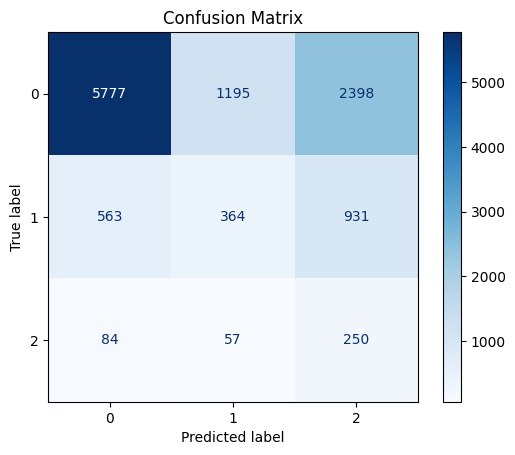

              precision    recall  f1-score   support

           0       0.90      0.62      0.73      9370
           1       0.23      0.20      0.21      1858
           2       0.07      0.64      0.13       391

    accuracy                           0.55     11619
   macro avg       0.40      0.48      0.36     11619
weighted avg       0.76      0.55      0.63     11619



In [51]:
model_scoring(y_pred, y_test)

# Feature Scaling

In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

In [54]:
x_train_scaled.head()

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Customer_Location_A,Customer_Location_B,Customer_Location_C,Customer_Location_D,Customer_Location_E,Customer_Location_F,Customer_Location_G,Customer_Location_Unknown
0,-0.629732,0.508780,-0.916615,-0.581552,0.723768,0.000273,-1.147274,-0.099911,-0.635316,-0.146006,-0.261901,-0.304488,-0.346054,-0.419346,-0.261525,1.387766,-0.449037
1,-0.629732,0.911032,-0.916615,-0.581552,-0.235298,-1.586458,-0.454780,0.691252,-0.635316,-0.146006,-0.261901,-0.304488,-0.346054,-0.419346,-0.261525,1.387766,-0.449037
2,-0.629732,-0.295726,1.090970,-0.581552,-0.235298,0.000273,-0.141684,-0.687168,-0.456374,-0.146006,-0.261901,-0.304488,-0.346054,2.384663,-0.261525,-0.720582,-0.449037
3,1.587978,-0.798542,-0.916615,1.555897,1.682834,0.000273,-0.554234,-0.687168,-0.635316,-0.146006,-0.261901,-0.304488,-0.346054,2.384663,-0.261525,-0.720582,-0.449037
4,-0.629732,-1.100231,-0.916615,1.555897,1.762756,-1.586458,-0.664739,-1.166662,-0.635316,-0.146006,-0.261901,-0.304488,-0.346054,-0.419346,-0.261525,1.387766,-0.449037


In [55]:
x_test_scaled.head()

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Customer_Location_A,Customer_Location_B,Customer_Location_C,Customer_Location_D,Customer_Location_E,Customer_Location_F,Customer_Location_G,Customer_Location_Unknown
0,-0.629732,-0.798542,-0.916615,1.555897,0.004468,0.000273,0.617112,2.139219,2.227762,-0.146006,-0.261901,-0.304488,-0.346054,-0.419346,-0.261525,1.387766,-0.449037
1,-0.629732,0.106527,1.090970,-0.581552,-0.714832,0.000273,1.681638,0.237848,-0.635316,-0.146006,-0.261901,-0.304488,-0.346054,-0.419346,-0.261525,-0.720582,2.226988
2,-0.629732,0.005964,1.090970,-0.581552,0.084390,1.587004,1.154900,-1.166662,-0.635316,-0.146006,-0.261901,3.284197,-0.346054,-0.419346,-0.261525,-0.720582,-0.449037
3,1.587978,-0.597415,-0.916615,-0.581552,-1.114442,0.000273,0.079324,-1.166662,-0.635316,-0.146006,-0.261901,3.284197,-0.346054,-0.419346,-0.261525,-0.720582,-0.449037
4,1.587978,-0.597415,-0.916615,-0.581552,0.883612,0.000273,-0.451097,0.546061,0.259396,-0.146006,-0.261901,3.284197,-0.346054,-0.419346,-0.261525,-0.720582,-0.449037


In [56]:
lr = LogisticRegression(
    class_weight='balanced',
    C=0.1,
    solver='saga',
    max_iter=1500,
)
lr.fit(x_train_scaled, y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1500, solver='saga')

In [57]:
y_pred = lr.predict(x_test)

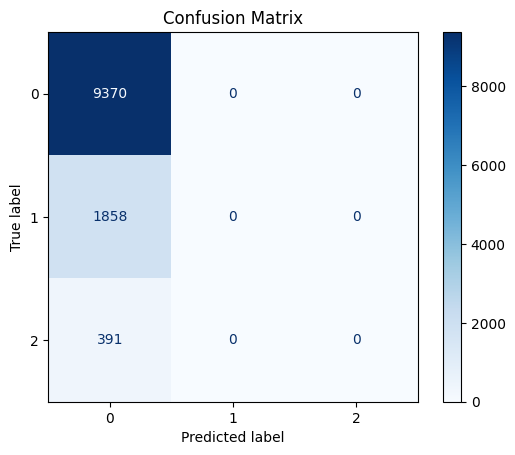

              precision    recall  f1-score   support

           0       0.81      1.00      0.89      9370
           1       1.00      0.00      0.00      1858
           2       1.00      0.00      0.00       391

    accuracy                           0.81     11619
   macro avg       0.94      0.33      0.30     11619
weighted avg       0.84      0.81      0.72     11619



In [58]:
model_scoring(y_pred, y_test)

- Scaling is reducing the performance and only predicting the 0 class correctly so we will not use scaling

# Prediction Using Models

In [59]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

### Support Vector Classifier

Training Scores:


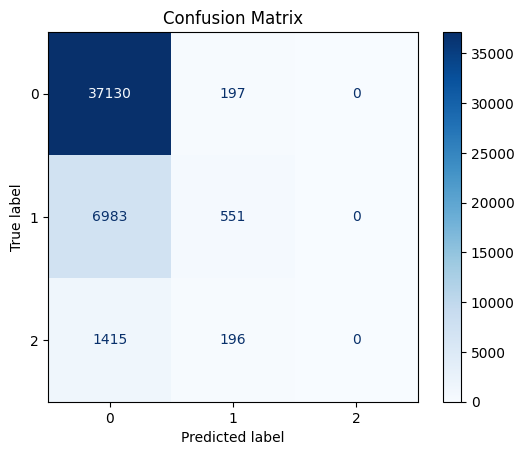

              precision    recall  f1-score   support

           0       0.82      0.99      0.90     37327
           1       0.58      0.07      0.13      7534
           2       1.00      0.00      0.00      1611

    accuracy                           0.81     46472
   macro avg       0.80      0.36      0.34     46472
weighted avg       0.78      0.81      0.74     46472


Testing Scores:


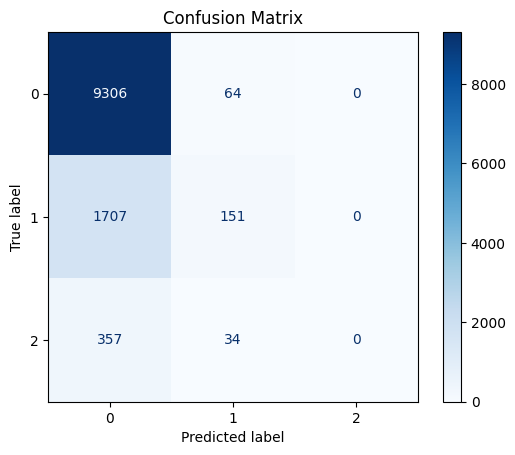

              precision    recall  f1-score   support

           0       0.82      0.99      0.90      9370
           1       0.61      0.08      0.14      1858
           2       1.00      0.00      0.00       391

    accuracy                           0.81     11619
   macro avg       0.81      0.36      0.35     11619
weighted avg       0.79      0.81      0.75     11619


Total execution time: 352.3215 seconds


In [75]:
# svr_w = SVC()
# svr_w.fit(x_train_scaled, y_train)

# print("Training Scores:")
# model_scoring(svr_w.predict(x_train_scaled), y_train)

# print("\nTesting Scores:")
# model_scoring(svr_w.predict(x_test_scaled), y_test)
import time

start = time.time()

# --- your code ---
svr_w = SVC()
svr_w.fit(x_train_scaled, y_train)

print("Training Scores:")
model_scoring(svr_w.predict(x_train_scaled), y_train)

print("\nTesting Scores:")
model_scoring(svr_w.predict(x_test_scaled), y_test)
# -----------------

end = time.time()
print(f"\nTotal execution time: {end - start:.4f} seconds")



Training Scores:


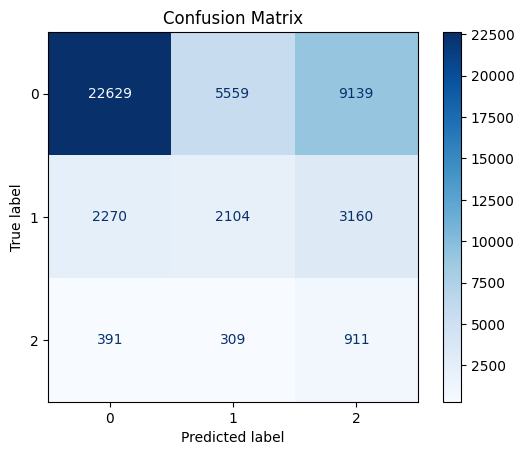

              precision    recall  f1-score   support

           0       0.89      0.61      0.72     37327
           1       0.26      0.28      0.27      7534
           2       0.07      0.57      0.12      1611

    accuracy                           0.55     46472
   macro avg       0.41      0.48      0.37     46472
weighted avg       0.76      0.55      0.63     46472


Testing Scores:


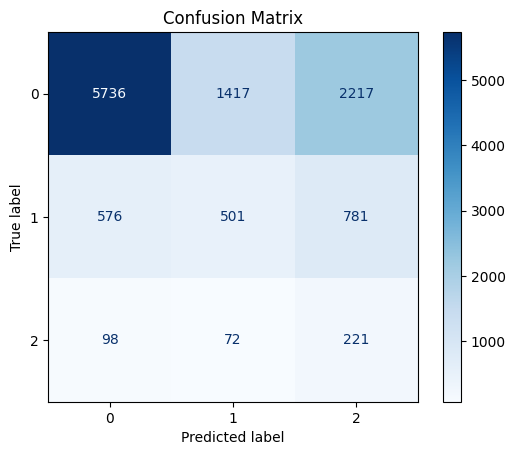

              precision    recall  f1-score   support

           0       0.89      0.61      0.73      9370
           1       0.25      0.27      0.26      1858
           2       0.07      0.57      0.12       391

    accuracy                           0.56     11619
   macro avg       0.41      0.48      0.37     11619
weighted avg       0.76      0.56      0.63     11619



In [71]:
svc = SVC(class_weight='balanced')
svc.fit(x_train, y_train)

print("Training Scores:")
model_scoring(svc.predict(x_train), y_train)

print("\nTesting Scores:")
model_scoring(svc.predict(x_test), y_test)

### Decision Tree Classifier

Training Scores:


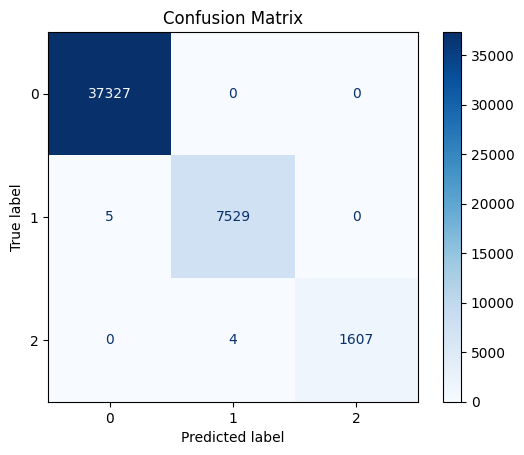

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37327
           1       1.00      1.00      1.00      7534
           2       1.00      1.00      1.00      1611

    accuracy                           1.00     46472
   macro avg       1.00      1.00      1.00     46472
weighted avg       1.00      1.00      1.00     46472


Testing Scores:


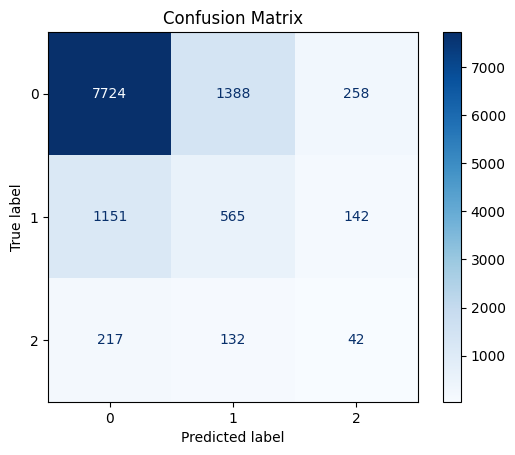

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      9370
           1       0.27      0.30      0.29      1858
           2       0.10      0.11      0.10       391

    accuracy                           0.72     11619
   macro avg       0.41      0.41      0.41     11619
weighted avg       0.73      0.72      0.72     11619



In [62]:
dtc = DecisionTreeClassifier()
dtc.fit(x_train, y_train)

print("Training Scores:")
model_scoring(dtc.predict(x_train), y_train)

print("\nTesting Scores:")
model_scoring(dtc.predict(x_test), y_test)

Training Scores:


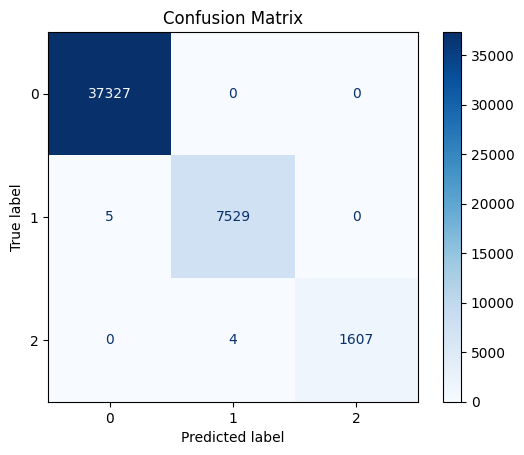

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37327
           1       1.00      1.00      1.00      7534
           2       1.00      1.00      1.00      1611

    accuracy                           1.00     46472
   macro avg       1.00      1.00      1.00     46472
weighted avg       1.00      1.00      1.00     46472


Testing Scores:


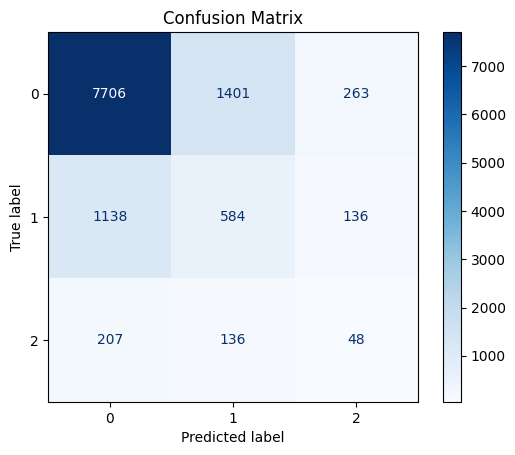

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      9370
           1       0.28      0.31      0.29      1858
           2       0.11      0.12      0.11       391

    accuracy                           0.72     11619
   macro avg       0.41      0.42      0.41     11619
weighted avg       0.73      0.72      0.73     11619



In [63]:
dtc = DecisionTreeClassifier()
dtc.fit(x_train, y_train)

print("Training Scores:")
model_scoring(dtc.predict(x_train), y_train)

print("\nTesting Scores:")
model_scoring(dtc.predict(x_test), y_test)

### Random Forest Classifier

Training Scores:


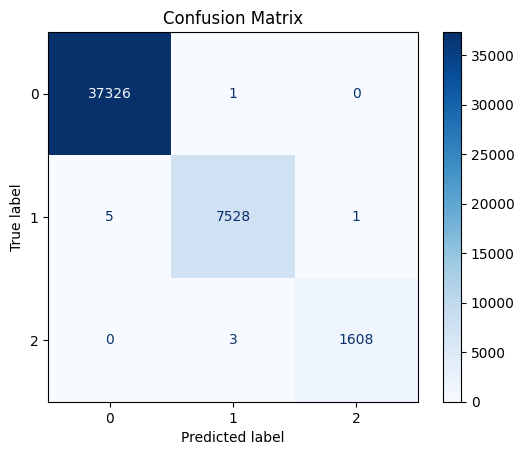

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37327
           1       1.00      1.00      1.00      7534
           2       1.00      1.00      1.00      1611

    accuracy                           1.00     46472
   macro avg       1.00      1.00      1.00     46472
weighted avg       1.00      1.00      1.00     46472


Testing Scores:


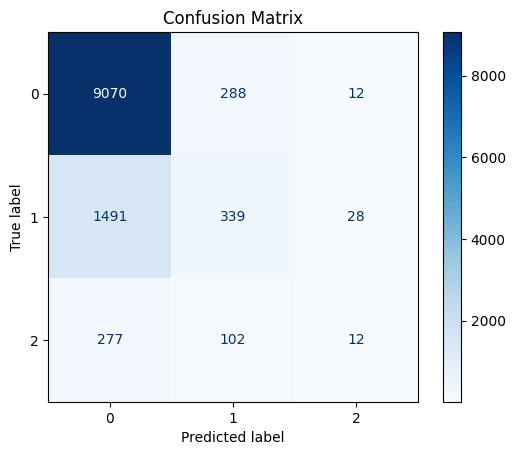

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      9370
           1       0.47      0.18      0.26      1858
           2       0.23      0.03      0.05       391

    accuracy                           0.81     11619
   macro avg       0.51      0.39      0.40     11619
weighted avg       0.76      0.81      0.77     11619



In [64]:
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)

print("Training Scores:")
model_scoring(rfc.predict(x_train), y_train)

print("\nTesting Scores:")
model_scoring(rfc.predict(x_test), y_test)

Training Scores:


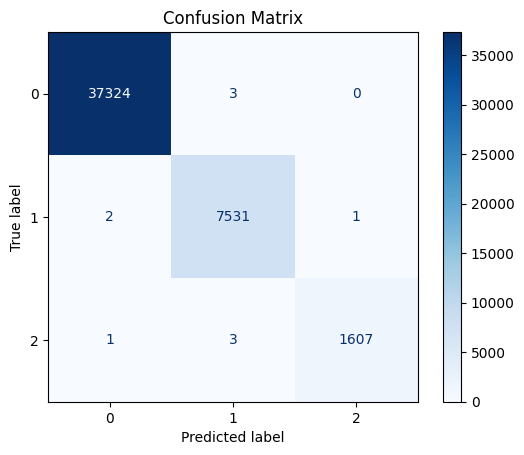

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37327
           1       1.00      1.00      1.00      7534
           2       1.00      1.00      1.00      1611

    accuracy                           1.00     46472
   macro avg       1.00      1.00      1.00     46472
weighted avg       1.00      1.00      1.00     46472


Testing Scores:


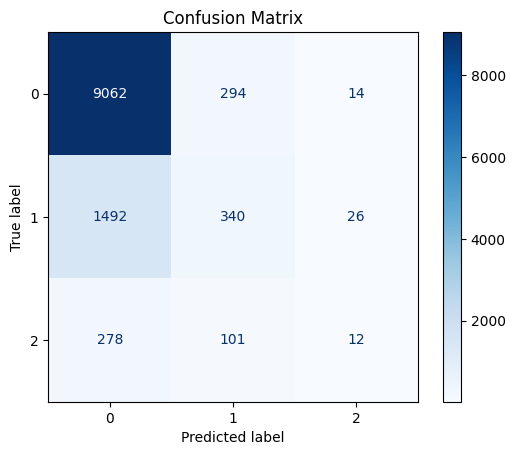

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      9370
           1       0.46      0.18      0.26      1858
           2       0.23      0.03      0.05       391

    accuracy                           0.81     11619
   macro avg       0.51      0.39      0.40     11619
weighted avg       0.76      0.81      0.77     11619



In [65]:
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)

print("Training Scores:")
model_scoring(rfc.predict(x_train), y_train)

print("\nTesting Scores:")
model_scoring(rfc.predict(x_test), y_test)

### Gradient Boosting Classifier

Training Scores:


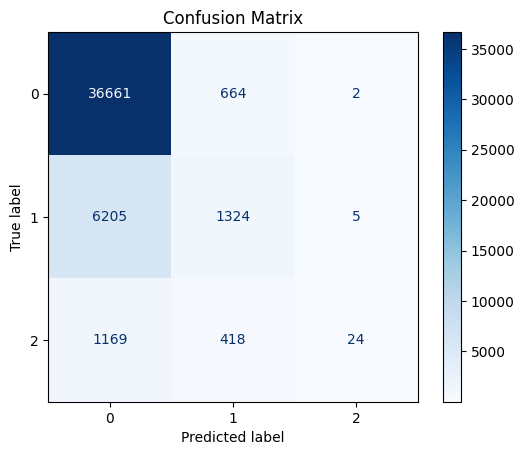

              precision    recall  f1-score   support

           0       0.83      0.98      0.90     37327
           1       0.55      0.18      0.27      7534
           2       0.77      0.01      0.03      1611

    accuracy                           0.82     46472
   macro avg       0.72      0.39      0.40     46472
weighted avg       0.78      0.82      0.77     46472


Testing Scores:


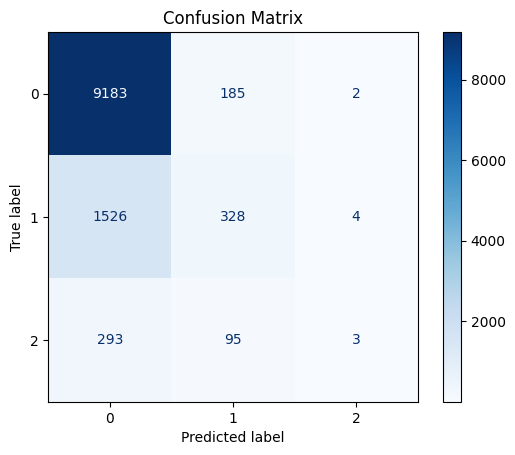

              precision    recall  f1-score   support

           0       0.83      0.98      0.90      9370
           1       0.54      0.18      0.27      1858
           2       0.33      0.01      0.01       391

    accuracy                           0.82     11619
   macro avg       0.57      0.39      0.39     11619
weighted avg       0.77      0.82      0.77     11619



In [66]:
gbc = GradientBoostingClassifier()
gbc.fit(x_train, y_train)

print("Training Scores:")
model_scoring(gbc.predict(x_train), y_train)

print("\nTesting Scores:")
model_scoring(gbc.predict(x_test), y_test)

### XGBoost Classifier

Training Scores:


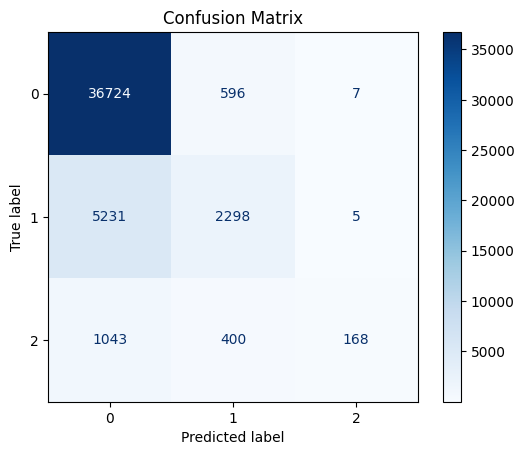

              precision    recall  f1-score   support

           0       0.85      0.98      0.91     37327
           1       0.70      0.31      0.42      7534
           2       0.93      0.10      0.19      1611

    accuracy                           0.84     46472
   macro avg       0.83      0.46      0.51     46472
weighted avg       0.83      0.84      0.81     46472


Testing Scores:


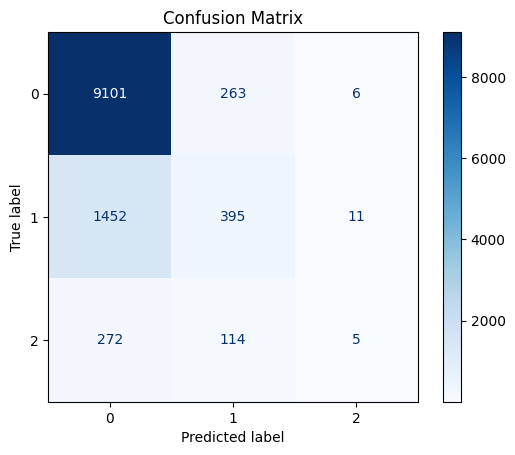

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      9370
           1       0.51      0.21      0.30      1858
           2       0.23      0.01      0.02       391

    accuracy                           0.82     11619
   macro avg       0.53      0.40      0.41     11619
weighted avg       0.77      0.82      0.78     11619



In [67]:
xgbc = XGBClassifier()
xgbc.fit(x_train, y_train)

print("Training Scores:")
model_scoring(xgbc.predict(x_train), y_train)

print("\nTesting Scores:")
model_scoring(xgbc.predict(x_test), y_test)

### Light GBM Classifier 

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001850 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 377
[LightGBM] [Info] Number of data points in the train set: 46472, number of used features: 17
[LightGBM] [Info] Start training from score -0.219133
[LightGBM] [Info] Start training from score -1.819424
[LightGBM] [Info] Start training from score -3.361995
Training Scores:


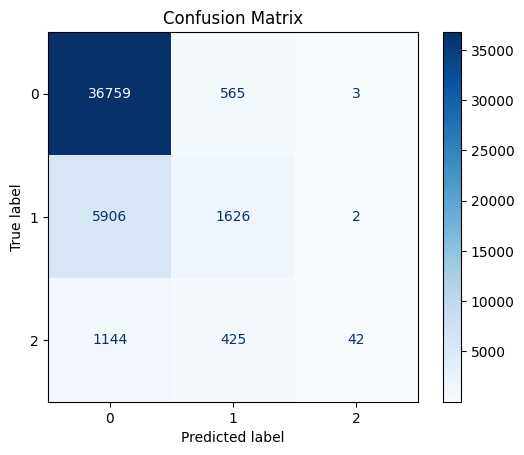

              precision    recall  f1-score   support

           0       0.84      0.98      0.91     37327
           1       0.62      0.22      0.32      7534
           2       0.89      0.03      0.05      1611

    accuracy                           0.83     46472
   macro avg       0.78      0.41      0.43     46472
weighted avg       0.81      0.83      0.78     46472


Testing Scores:


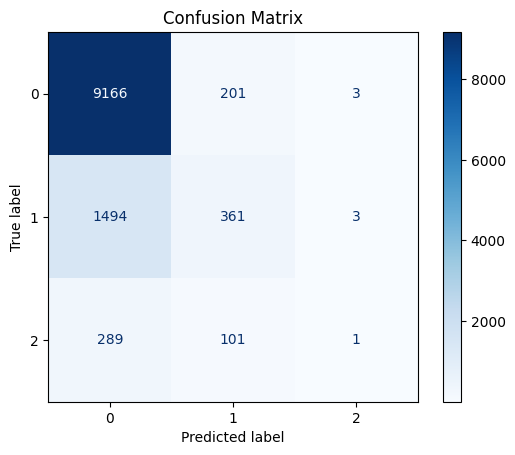

              precision    recall  f1-score   support

           0       0.84      0.98      0.90      9370
           1       0.54      0.19      0.29      1858
           2       0.14      0.00      0.01       391

    accuracy                           0.82     11619
   macro avg       0.51      0.39      0.40     11619
weighted avg       0.77      0.82      0.77     11619



In [68]:
lgbc = LGBMClassifier()
lgbc.fit(x_train, y_train)

print("Training Scores:")
model_scoring(lgbc.predict(x_train), y_train)

print("\nTesting Scores:")
model_scoring(lgbc.predict(x_test), y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001574 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 377
[LightGBM] [Info] Number of data points in the train set: 46472, number of used features: 17
[LightGBM] [Info] Start training from score -0.219133
[LightGBM] [Info] Start training from score -1.819424
[LightGBM] [Info] Start training from score -3.361995
Training Scores:


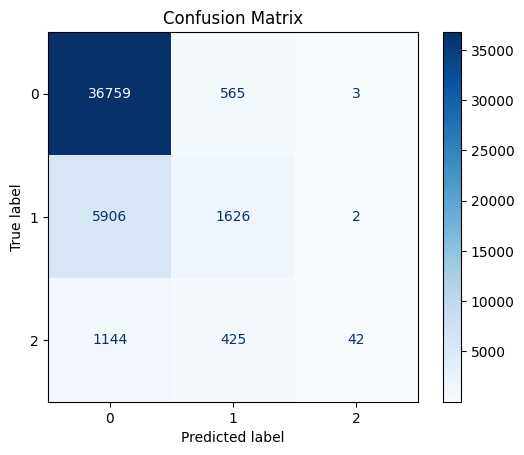

              precision    recall  f1-score   support

           0       0.84      0.98      0.91     37327
           1       0.62      0.22      0.32      7534
           2       0.89      0.03      0.05      1611

    accuracy                           0.83     46472
   macro avg       0.78      0.41      0.43     46472
weighted avg       0.81      0.83      0.78     46472


Testing Scores:


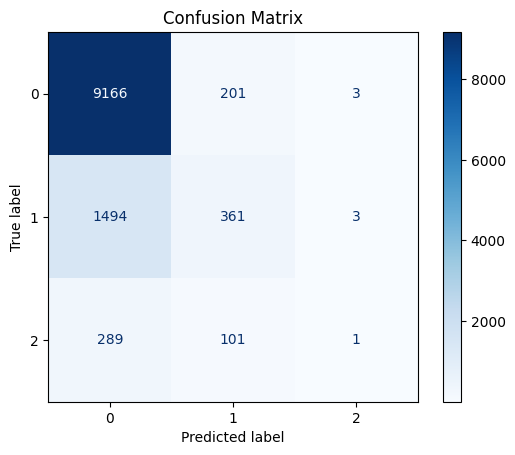

              precision    recall  f1-score   support

           0       0.84      0.98      0.90      9370
           1       0.54      0.19      0.29      1858
           2       0.14      0.00      0.01       391

    accuracy                           0.82     11619
   macro avg       0.51      0.39      0.40     11619
weighted avg       0.77      0.82      0.77     11619



In [69]:
lgbmc = LGBMClassifier()
lgbmc.fit(x_train, y_train)

print("Training Scores:")
model_scoring(lgbmc.predict(x_train), y_train)

print("\nTesting Scores:")
model_scoring(lgbmc.predict(x_test), y_test)

### Scoring

In [70]:
final_result = pd.DataFrame({'Model':[
    "SVC",
    "SVC without Scaling",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
    "XGBoostClassifier",
    "LightGBMClassifier"
    ], 
'Train Score':[
    f1_score(svc.predict(x_train), y_train, average='weighted')*100,
    f1_score(svr_w.predict(x_train), y_train, average='weighted')*100,
    f1_score(dtc.predict(x_train), y_train, average='weighted')*100,
    f1_score(rfc.predict(x_train), y_train, average='weighted')*100,
    f1_score(gbc.predict(x_train), y_train, average='weighted')*100,
    f1_score(xgbc.predict(x_train), y_train, average='weighted')*100,  
    f1_score(lgbmc.predict(x_train), y_train, average='weighted')*100
    ], 
'Test Score':[
    f1_score(svc.predict(x_test), y_test, average='weighted')*100,
    f1_score(svr_w.predict(x_test), y_test, average='weighted')*100,
    f1_score(dtc.predict(x_test), y_test, average='weighted')*100,
    f1_score(rfc.predict(x_test), y_test, average='weighted')*100,
    f1_score(gbc.predict(x_test), y_test, average='weighted')*100,
    f1_score(xgbc.predict(x_test), y_test, average='weighted')*100,
    f1_score(lgbmc.predict(x_test), y_test, average='weighted')*100
    ]
})
final_result

,Model,Train Score,Test Score
0,SVC,47.483140,47.959020
1,SVC without Scaling,89.086982,89.284863
2,DecisionTreeClassifier,99.980639,70.973079
3,RandomForestClassifier,99.978485,85.320384
4,GradientBoostingClassifier,86.773598,86.758960
5,XGBoostClassifier,87.684334,85.972380
6,LightGBMClassifier,87.227210,86.652975


- At last we can say that SVC with scaling is the best algorith for this dataset